<a href="https://colab.research.google.com/github/thomaslu678/Praxis-Lab-25-26/blob/main/clean/14_VIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTE: Requires calculations_df

In [40]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta
import scipy.stats as stats
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Point
import requests
import random
import os
import math
import copy
import sys
import gc
from io import StringIO

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap

import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load datasets for tree patches

## Process zonal stats

In [ ]:
zonal_stats_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/Trees ML/0_grid_zonal_statistics.csv')

In [ ]:
zonal_stats_df

,grid_id,row_index,col_index,red_count,red_sum,red_mean,green_count,green_sum,green_mean,blue_count,blue_sum,blue_mean,nir_count,nir_sum,nir_mean
0,92,91,0,2500,360989,144.395600,2500,364042,145.616800,2500,350403,140.161200,2500,347438,138.975200
1,93,92,0,2497,393822,157.718062,2497,398207,159.474169,2497,370796,148.496596,2497,435716,174.495795
2,94,93,0,2500,331540,132.616000,2500,338398,135.359200,2500,317191,126.876400,2500,424710,169.884000
3,95,94,0,2500,329664,131.865600,2500,336571,134.628400,2500,307081,122.832400,2500,438324,175.329600
4,96,95,0,2500,340133,136.053200,2500,344242,137.696800,2500,320666,128.266400,2500,419598,167.839200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7264,8106,5,75,2493,380147,152.485760,2493,380885,152.781789,2493,356467,142.987164,2493,370392,148.572804
7265,8107,6,75,2497,348732,139.660392,2497,359190,143.848618,2497,349611,140.012415,2497,317664,127.218262
7266,8108,7,75,2497,339403,135.924309,2497,348492,139.564277,2497,340254,136.265118,2497,332410,133.123748
7267,8214,5,76,2497,472292,189.143773,2497,477485,191.223468,2497,448381,179.567881,2497,496012,198.643172


In [ ]:
print(zonal_stats_df['red_count'].unique(),
      zonal_stats_df['green_count'].unique(),
      zonal_stats_df['blue_count'].unique(),
      zonal_stats_df['nir_count'].unique())

[2500 2497 2493 2498 2499 2496 2494 2495] [2500 2497 2493 2498 2499 2496 2494 2495] [2500 2497 2493 2498 2499 2496 2494 2495] [2500 2497 2493 2498 2499 2496 2494 2495]


In [ ]:
# zonal_stats_df = zonal_stats_df.drop(columns=['red_count', 'green_count', 'blue_count', 'nir_count'])

In [ ]:
# zonal_stats_df

## Process RGBALL

In [ ]:
rgbn_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/Trees ML/0_rgbn_grid_radii.csv')

In [ ]:
rgbn_df

,RED,GREEN,BLUE,NIR,grid_id,radii_id
0,187,186,175,170,4713,1
1,187,186,174,170,4713,1
2,187,186,174,170,4713,1
3,187,186,174,170,4713,1
4,187,187,176,170,4713,1
...,...,...,...,...,...,...
573275,129,140,134,164,5706,110292
573276,108,123,115,183,5706,110292
573277,110,122,113,168,5706,110292
573278,165,168,158,171,5706,110292


In [ ]:
rgbn_df['grid_id'].isna().sum()

np.int64(0)

In [ ]:
# rgbn_df = rgbn_df.dropna()

In [ ]:
rgbn_df.isna().sum()

,0
RED,0
GREEN,0
BLUE,0
NIR,0
grid_id,0
radii_id,0


In [ ]:
rgbn_df['grid_id'].dtype

dtype('int64')

In [ ]:
# rgbn_df['grid_id'] = rgbn_df['grid_id'].astype(int)

In [ ]:
rgbn_df['grid_id']

,grid_id
0,4713
1,4713
2,4713
3,4713
4,4713
...,...
573275,5706
573276,5706
573277,5706
573278,5706


## Process radii df

In [ ]:
radii_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/Trees ML/0_trees.csv')

In [ ]:
# radii_df['Vacant'].unique()

In [ ]:
# radii_df = radii_df.drop(columns=['Vacant'])

In [ ]:
radii_df

,radii_id,SPP,DBH,grid_id
0,1,Zelkova serrata,10,4714.0
1,4,Zelkova species,12,4712.0
2,5,Zelkova species,9,4712.0
3,7,Zelkova species,10,4711.0
4,8,Zelkova species,9,4711.0
...,...,...,...,...
4385,108092,Gleditsia triacanthos,13,8954.0
4386,110208,Tilia cordata,19,6798.0
4387,110290,Pyrus calleryana,2,5706.0
4388,110291,Pyrus calleryana,2,5706.0


In [ ]:
radii_df.isna().sum()

,0
radii_id,0
SPP,0
DBH,0
grid_id,143


In [ ]:
radii_df = radii_df.dropna()

In [ ]:
radii_df.isna().sum()

,0
radii_id,0
SPP,0
DBH,0
grid_id,0


## Process grids

In [ ]:
zonal_stats_df.columns

Index(['grid_id', 'row_index', 'col_index', 'red_count', 'red_sum', 'red_mean',
       'green_count', 'green_sum', 'green_mean', 'blue_count', 'blue_sum',
       'blue_mean', 'nir_count', 'nir_sum', 'nir_mean'],
      dtype='object')

In [ ]:
grids_df = zonal_stats_df[['grid_id', 'row_index', 'col_index']].copy()

In [ ]:
grids_df

,grid_id,row_index,col_index
0,92,91,0
1,93,92,0
2,94,93,0
3,95,94,0
4,96,95,0
...,...,...,...
7264,8106,5,75
7265,8107,6,75
7266,8108,7,75
7267,8214,5,76


In [ ]:
grids_df['grid_id'].isna().sum()

np.int64(0)

In [ ]:
np.min(grids_df['grid_id'])

92

In [ ]:
np.max(grids_df['grid_id'])

13709

## Process radii to grid id

In [ ]:
radii_df.columns

Index(['radii_id', 'SPP', 'DBH', 'grid_id'], dtype='object')

In [ ]:
radii_to_grid_df = radii_df[['radii_id', 'grid_id']].copy()

In [ ]:
radii_to_grid_df

,radii_id,grid_id
0,1,4714.0
1,4,4712.0
2,5,4712.0
3,7,4711.0
4,8,4711.0
...,...,...
4385,108092,8954.0
4386,110208,6798.0
4387,110290,5706.0
4388,110291,5706.0


In [ ]:
radii_to_grid_df['grid_id'].isna().sum()

np.int64(0)

In [ ]:
radii_to_grid_df['grid_id'].dtype

dtype('float64')

In [ ]:
radii_to_grid_df['grid_id'] = radii_to_grid_df['grid_id'].astype(int)

In [ ]:
radii_to_grid_df['grid_id'].dtype

dtype('int64')

## Confirm alignment

In [ ]:
# zonal_stats_df
# grids_df
# radii_df
# rgbn_df

In [ ]:
print("Grids: ", np.min(zonal_stats_df['grid_id']), np.max(zonal_stats_df['grid_id']))

Grids:  92 13709


In [ ]:
print("Grids: ", np.min(grids_df['grid_id']), np.max(grids_df['grid_id']))

Grids:  92 13709


In [ ]:
print("Radii: ", np.min(radii_df['radii_id']), np.max(radii_df['radii_id']))

Radii:  1 110292


In [ ]:
print("Grids: ", np.min(rgbn_df['grid_id']), np.max(rgbn_df['grid_id']))

Grids:  93 13601


In [ ]:
print("Radii: ", np.min(rgbn_df['radii_id']), np.max(rgbn_df['radii_id']))

Radii:  1 110292


In [ ]:
# 1. Check if all in zonal_stats_df
check1 = rgbn_df['grid_id'].isin(zonal_stats_df['grid_id']).all()

# 2. Check if all in grids_df
check2 = rgbn_df['grid_id'].isin(grids_df['grid_id']).all()

# 3. Final check: True if both conditions are met
all_present = check1 and check2

print(f"All present: {all_present}")

All present: True


In [ ]:
print(f"All present: {rgbn_df['radii_id'].isin(radii_df['radii_id']).all()}")

All present: False


In [ ]:
print(len(rgbn_df[rgbn_df['radii_id'].isin(radii_df['radii_id'])]))
print(len(rgbn_df[~rgbn_df['radii_id'].isin(radii_df['radii_id'])]))
print(len(rgbn_df))

573279
1
573280


In [ ]:
rgbn_df = rgbn_df[rgbn_df['radii_id'].isin(radii_df['radii_id'])]

In [ ]:
print(f"All present: {rgbn_df['radii_id'].isin(radii_df['radii_id']).all()}")

All present: True


In [ ]:
9290 in radii_df['radii_id']

False

In [ ]:
print(f"All present: {radii_df['radii_id'].isin(radii_to_grid_df['radii_id']).all()}")

All present: True


# Prepare processing tree patches

In [ ]:
# zonal_stats_df
# grids_df
# radii_df
# rgbn_df

In [ ]:
filtered_radii_df = radii_df[radii_df['radii_id'].isin(rgbn_df['radii_id'])].copy()

In [ ]:
radii_df

,radii_id,SPP,DBH,grid_id
0,1,Zelkova serrata,10,4714.0
1,4,Zelkova species,12,4712.0
2,5,Zelkova species,9,4712.0
3,7,Zelkova species,10,4711.0
4,8,Zelkova species,9,4711.0
...,...,...,...,...
4385,108092,Gleditsia triacanthos,13,8954.0
4386,110208,Tilia cordata,19,6798.0
4387,110290,Pyrus calleryana,2,5706.0
4388,110291,Pyrus calleryana,2,5706.0


In [ ]:
filtered_radii_df

,radii_id,SPP,DBH,grid_id
0,1,Zelkova serrata,10,4714.0
1,4,Zelkova species,12,4712.0
2,5,Zelkova species,9,4712.0
3,7,Zelkova species,10,4711.0
4,8,Zelkova species,9,4711.0
...,...,...,...,...
4385,108092,Gleditsia triacanthos,13,8954.0
4386,110208,Tilia cordata,19,6798.0
4387,110290,Pyrus calleryana,2,5706.0
4388,110291,Pyrus calleryana,2,5706.0


In [ ]:
filtered_radii_df.isna().sum()

,0
radii_id,0
SPP,0
DBH,0
grid_id,0


In [ ]:
filtered_radii_df['grid_id'].dtype

dtype('float64')

In [ ]:
filtered_radii_df['grid_id'] = filtered_radii_df['grid_id'].astype(int)

In [ ]:
filtered_radii_df['grid_id'].dtype

dtype('int64')

In [ ]:
filtered_radii_df

,radii_id,SPP,DBH,grid_id
0,1,Zelkova serrata,10,4714
1,4,Zelkova species,12,4712
2,5,Zelkova species,9,4712
3,7,Zelkova species,10,4711
4,8,Zelkova species,9,4711
...,...,...,...,...
4385,108092,Gleditsia triacanthos,13,8954
4386,110208,Tilia cordata,19,6798
4387,110290,Pyrus calleryana,2,5706
4388,110291,Pyrus calleryana,2,5706


# Process raw data into grid/radii id before/after

In [ ]:
# Initialize list to collect results
rows = []

In [ ]:
subset = rgbn_df[rgbn_df['radii_id'] == 1]

In [ ]:
subset

,RED,GREEN,BLUE,NIR,grid_id,radii_id
0,187,186,175,170,4713,1
1,187,186,174,170,4713,1
2,187,186,174,170,4713,1
3,187,186,174,170,4713,1
4,187,187,176,170,4713,1
...,...,...,...,...,...,...
111,220,214,198,198,4714,1
112,213,208,192,194,4714,1
113,206,202,187,189,4714,1
114,208,205,190,194,4714,1


In [ ]:
pix = subset[subset['grid_id'] == 4713]

In [ ]:
pix

,RED,GREEN,BLUE,NIR,grid_id,radii_id
0,187,186,175,170,4713,1
1,187,186,174,170,4713,1
2,187,186,174,170,4713,1
3,187,186,174,170,4713,1
4,187,187,176,170,4713,1
5,185,184,172,170,4713,1
6,186,185,173,170,4713,1
7,186,186,174,170,4713,1
8,187,186,174,172,4713,1
9,187,186,174,172,4713,1


In [ ]:
zonal_stats_df[zonal_stats_df['grid_id'] == 4713].iloc[0]

,6391
grid_id,4713.0000
row_index,68.0000
col_index,43.0000
red_count,2500.0000
red_sum,407892.0000
red_mean,163.1568
green_count,2500.0000
green_sum,416425.0000
green_mean,166.5700
blue_count,2500.0000


In [ ]:
pix['RED'].sum()

np.int64(7416)

In [ ]:
# Loop over each radius (fid)
for fid in filtered_radii_df['radii_id'].unique():

    # Subset rgbn_df for this radii_id
    subset = rgbn_df[rgbn_df['radii_id'] == fid]

    # Get unique grid_ids for this radius
    grid_ids = subset['grid_id'].unique()

    for gid in grid_ids:

        # Subset pixels for this grid_id + radii_id
        pix = subset[subset['grid_id'] == gid]

        # Get zonal stats row
        zs_row = zonal_stats_df[zonal_stats_df['grid_id'] == gid].iloc[0]

        # BEFORE values (means already computed)
        before_red = zs_row['red_mean']
        before_green = zs_row['green_mean']
        before_blue = zs_row['blue_mean']
        before_nir = zs_row['nir_mean']

        # ORIGINAL sums
        red_sum = zs_row['red_sum']
        green_sum = zs_row['green_sum']
        blue_sum = zs_row['blue_sum']
        nir_sum = zs_row['nir_sum']

        red_count = zs_row['red_count']
        green_count = zs_row['green_count']
        blue_count = zs_row['blue_count']
        nir_count = zs_row['nir_count']

        # Remove pixels inside radius
        removed_count = len(pix)

        # Subtract pixel values
        new_red_sum = red_sum - pix['RED'].sum()
        new_green_sum = green_sum - pix['GREEN'].sum()
        new_blue_sum = blue_sum - pix['BLUE'].sum()
        new_nir_sum = nir_sum - pix['NIR'].sum()

        # AFTER means
        after_red = new_red_sum / (red_count - removed_count) if red_count > 0 else None
        after_green = new_green_sum / (green_count - removed_count) if green_count > 0 else None
        after_blue = new_blue_sum / (blue_count - removed_count) if blue_count > 0 else None
        after_nir = new_nir_sum / (nir_count - removed_count) if nir_count > 0 else None

        # Append result
        rows.append({
            'grid_id': gid,
            'radii_id': fid,
            'before_red': before_red,
            'after_red': after_red,
            'before_green': before_green,
            'after_green': after_green,
            'before_blue': before_blue,
            'after_blue': after_blue,
            'before_nir': before_nir,
            'after_nir': after_nir
        })

In [ ]:
# Create final dataframe
result_df = pd.DataFrame(rows)

print(result_df.head())

   grid_id  radii_id  before_red   after_red  before_green  after_green  \
0     4713         1  163.156800  162.662876    166.570000   166.190089   
1     4714         1  176.186624  175.332369    176.368843   175.638280   
2     4712         4  163.377600  162.731011    165.856800   164.898028   
3     4713         4  163.156800  162.956698    166.570000   166.292594   
4     4712         5  163.377600  163.467695    165.856800   165.871613   

   before_blue  after_blue  before_nir   after_nir  
0   155.806400  155.464257  179.997600  179.901706  
1   165.299159  164.636627  180.563476  180.420835  
2   156.722800  155.711708  182.564000  180.994964  
3   155.806400  155.537030  179.997600  179.519628  
4   156.722800  156.484368  182.564000  181.899125  


In [ ]:
len(result_df['radii_id'].unique())

4099

In [ ]:
result_df

,grid_id,radii_id,before_red,after_red,before_green,after_green,before_blue,after_blue,before_nir,after_nir
0,4713,1,163.156800,162.662876,166.570000,166.190089,155.806400,155.464257,179.997600,179.901706
1,4714,1,176.186624,175.332369,176.368843,175.638280,165.299159,164.636627,180.563476,180.420835
2,4712,4,163.377600,162.731011,165.856800,164.898028,156.722800,155.711708,182.564000,180.994964
3,4713,4,163.156800,162.956698,166.570000,166.292594,155.806400,155.537030,179.997600,179.519628
4,4712,5,163.377600,163.467695,165.856800,165.871613,156.722800,156.484368,182.564000,181.899125
...,...,...,...,...,...,...,...,...,...,...
6182,6798,110208,132.549600,135.961933,136.632400,139.340462,132.030800,134.446108,141.544800,140.903764
6183,6906,110208,115.277600,115.754272,124.586400,124.966640,114.270000,114.456062,166.697600,167.005289
6184,5706,110290,182.357000,182.491341,185.326113,185.458317,182.846771,182.996375,171.239471,171.436569
6185,5706,110291,182.357000,182.570508,185.326113,185.512490,182.846771,183.055197,171.239471,171.325141


In [ ]:
zonal_stats_df[zonal_stats_df['grid_id'] == 4713]

,grid_id,row_index,col_index,red_count,red_sum,red_mean,green_count,green_sum,green_mean,blue_count,blue_sum,blue_mean,nir_count,nir_sum,nir_mean
6391,4713,68,43,2500,407892,163.1568,2500,416425,166.57,2500,389516,155.8064,2500,449994,179.9976


In [ ]:
# result_df.to_csv('0_radii_before_after_clean.csv')

# Generate patches for park #2

In [ ]:
point_row_col_df_2 = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/2/2_grids_clean.csv')

In [ ]:
point_row_col_df_2

,point_id,row_index,col_index
0,17,16,0
1,18,17,0
2,19,18,0
3,20,19,0
4,21,20,0
...,...,...,...
4889,7708,11,208
4890,7709,12,208
4891,7710,13,208
4892,7711,14,208


In [ ]:
lookup_2 = {(r,c):pid for r,c,pid in zip(point_row_col_df_2.row_index, point_row_col_df_2.col_index, point_row_col_df_2.point_id)}

In [ ]:
# Expect size to be an odd integer
def get_patches(df, size, lookup):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [ ]:
PATCH_SIZE = 5

In [ ]:
patches_2 = get_patches(point_row_col_df_2, PATCH_SIZE, lookup_2)
print(patches_2.shape)  # (#patches,5,5)

(3848, 5, 5)


In [ ]:
patches_2[0]

array([[ 17,  54,  91, 128, 165],
       [ 18,  55,  92, 129, 166],
       [ 19,  56,  93, 130, 167],
       [ 20,  57,  94, 131, 168],
       [ 21,  58,  95, 132, 169]])

# Generate patches for park #0 (Green Loop)

In [ ]:
point_row_col_df_0 = grids_df.copy()

In [ ]:
point_row_col_df_0

,grid_id,row_index,col_index
0,92,91,0
1,93,92,0
2,94,93,0
3,95,94,0
4,96,95,0
...,...,...,...
7264,8106,5,75
7265,8107,6,75
7266,8108,7,75
7267,8214,5,76


In [ ]:
lookup_0 = {(r,c):pid for r,c,pid in zip(point_row_col_df_0.row_index, point_row_col_df_0.col_index, point_row_col_df_0.grid_id)}

In [ ]:
PATCH_SIZE = 5

In [ ]:
patches_0 = get_patches(point_row_col_df_0, PATCH_SIZE, lookup_0)
print(patches_0.shape)  # (#patches,5,5)

(5961, 5, 5)


In [ ]:
patches_0[0]

array([[ 92, 200, 308, 416, 524],
       [ 93, 201, 309, 417, 525],
       [ 94, 202, 310, 418, 526],
       [ 95, 203, 311, 419, 527],
       [ 96, 204, 312, 420, 528]])

In [ ]:
len(patches_0)

5961

# Generate patches for tree (not run, should be same as Green Loop)

In [ ]:
tree_row_col_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_tree_row_col.csv')

In [ ]:
tree_row_col_df

,grid_id,row_index,col_index
0,92,91,0
1,93,92,0
2,94,93,0
3,95,94,0
4,96,95,0
...,...,...,...
6935,7691,22,71
6936,7692,23,71
6937,7693,24,71
6938,7694,25,71


In [ ]:
lookup = {(r,c):pid for r,c,pid in zip(tree_row_col_df.row_index, tree_row_col_df.col_index, tree_row_col_df.grid_id)}

In [ ]:
# Expect size to be an odd integer
def get_patches(df, size):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [ ]:
PATCH_SIZE = 5

In [ ]:
patches_tree_0 = get_patches(tree_row_col_df, PATCH_SIZE)
print(patches_tree_0.shape)  # (#patches,5,5)

(5624, 5, 5)


In [ ]:
patches_tree_0[0].shape

(5, 5)

# Load datasets to populate patches

## Train dataset

In [ ]:
train_df_load = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/2/2_landsat_clean.csv')

In [ ]:
train_df = train_df_load.copy()

In [ ]:
train_df['time'] = pd.to_datetime(train_df['time'], format='%Y-%m-%d %H:%M:%S')

In [ ]:
train_df

,point_id,time,Blue,Green,Red,NIR,LST_K
0,4227,1988-12-24 01:43:00,0.202545,0.201775,0.204415,0.213737,272.622947
1,4264,1988-12-24 01:43:00,0.192507,0.208980,0.210300,0.213737,272.622947
2,4301,1988-12-24 01:43:00,0.202545,0.208980,0.216240,0.213737,272.622947
3,4302,1988-12-24 01:43:00,0.195835,0.216158,0.210300,0.213737,272.622947
4,4338,1988-12-24 01:43:00,0.199162,0.208980,0.210300,0.213737,272.718652
...,...,...,...,...,...,...,...
2816682,3357,2026-03-20 02:10:58,0.057042,0.132777,0.161020,0.234060,288.759420
2816683,3358,2026-03-20 02:10:58,-0.026585,0.060590,0.073350,0.179308,288.598773
2816684,3359,2026-03-20 02:10:58,-0.022130,0.058802,0.055117,0.136407,288.369766
2816685,3360,2026-03-20 02:10:58,-0.016987,0.055557,0.053522,0.098677,288.147594


In [ ]:
train_df['point_id'].min()

17

In [ ]:
train_df['point_id'].max()

7712

## Predict dataset

In [ ]:
predict_df_load = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_landsat_clean.csv')

In [ ]:
predict_df = predict_df_load.copy()

In [ ]:
predict_df['time'] = pd.to_datetime(predict_df['time'], format='%Y-%m-%d %H:%M:%S')

In [ ]:
predict_df

,point_id,time,Blue,Green,Red,NIR,LST_K
0,1598,1982-11-19 17:36:28,0.111658,0.137095,0.120347,0.110805,280.665548
1,1818,1982-11-19 17:36:28,0.174220,0.207275,0.207632,0.206780,281.209014
2,1820,1982-11-19 17:36:28,0.139927,0.165282,0.167015,0.172570,280.665548
3,1927,1982-11-19 17:36:28,0.186622,0.228203,0.224985,0.227268,280.665548
4,2138,1982-11-19 17:36:28,0.143062,0.165282,0.178620,0.193112,281.752479
...,...,...,...,...,...,...,...
5926536,8106,2026-03-17 18:08:07,0.066062,0.080802,0.088722,0.156867,299.539855
5926537,8107,2026-03-17 18:08:07,0.088915,0.102032,0.114627,0.173038,298.897267
5926538,8108,2026-03-17 18:08:07,0.069528,0.098265,0.106817,0.222482,299.259577
5926539,8214,2026-03-17 18:08:07,0.173230,0.220832,0.245582,0.276245,299.806460


In [ ]:
print(predict_df['point_id'].min(), predict_df['point_id'].max())

92 13709


# Find closest date to update clip method

In [ ]:
# 7/8/24, 6:00 PM
# 7/6/24, 6:00 PM
# Source: https://opendata.gis.utah.gov/datasets/utah::utah-hexagon-service-dates/explore?location=39.499696%2C-111.531887%2C-1

In [ ]:
predict_df['time'].dtype

dtype('<M8[ns]')

In [ ]:
target_date = pd.to_datetime('2024-07-08')

In [ ]:
pre_target_date = predict_df[predict_df['time'] < target_date]

In [ ]:
unique_times = pre_target_date['time'].unique()

In [ ]:
closest_date = unique_times[abs(unique_times - target_date).argmin()]

In [ ]:
closest_date

Timestamp('2024-06-23 18:07:27')

In [ ]:
target_date

Timestamp('2024-07-08 00:00:00')

# Populate patches

### Populate definitions + method

In [ ]:
features = ['Blue', 'Green', 'Red', 'NIR']
target_col = 'LST_K'

In [ ]:
def populate_patches(input_df, input_patches, closest_date):

    # -------------------------
    # 1. Pivot
    # -------------------------
    df_pivot = input_df.pivot(
        index='time',
        columns='point_id',
        values=features + [target_col]
    ).sort_index()

    times = df_pivot.index.values
    point_ids = df_pivot.columns.levels[1].values

    # -------------------------
    # 2. Build feature tensor CORRECTLY
    # -------------------------
    # stack each feature explicitly to preserve alignment
    X = np.stack(
        [df_pivot[feat].values for feat in features],
        axis=-1
    )
    # shape: (T, P, F)

    y = df_pivot[target_col].values  # (T, P)

    # -------------------------
    # 3. point_id → index
    # -------------------------
    point_id_to_idx = {pid: i for i, pid in enumerate(point_ids)}

    all_patches_cubes = []
    all_patches_targets = []
    all_patches_times = []

    for patch in input_patches:
        patch = np.array(patch)
        flat_ids = patch.flatten()

        # map indices safely
        if not all(pid in point_id_to_idx for pid in flat_ids):
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        idxs = np.array([point_id_to_idx[pid] for pid in flat_ids])
        center_idx = point_id_to_idx[patch[2, 2]]

        # extract all times at once
        patch_data = X[:, idxs, :]   # (T, 25, F)

        # -------------------------
        # NEW: time filter
        # -------------------------
        time_mask = times <= np.datetime64(closest_date)

        # validity mask
        valid_mask = ~np.isnan(patch_data).any(axis=(1, 2))

        # combine both
        final_mask = valid_mask & time_mask

        if not final_mask.any():
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        valid_patch_data = patch_data[final_mask]
        valid_targets = y[final_mask, center_idx]
        valid_times = times[final_mask]

        # reshape to cubes
        cubes = valid_patch_data.reshape(-1, 5, 5, len(features))
        cubes = np.transpose(cubes, (0, 3, 1, 2))  # (Tv, F, 5, 5)

        all_patches_cubes.append(cubes)
        all_patches_targets.append(valid_targets)
        all_patches_times.append(valid_times)

    return all_patches_cubes, all_patches_targets, all_patches_times

In [ ]:
now = np.datetime64('now')

### Populate #0 patches

In [ ]:
cubes_0, targets_0, times_0 = populate_patches(predict_df, patches_0, now)

In [ ]:
len(cubes_0)

5961

In [ ]:
len(patches_0)

5961

In [ ]:
len(cubes_0[0])

796

In [ ]:
cubes_0[0][0]

array([[[0.189125 , 0.1840375, 0.184065 , 0.1874475, 0.1806275],
        [0.1823325, 0.1823325, 0.17554  , 0.17554  , 0.1857425],
        [0.1738625, 0.1823325, 0.184065 , 0.177245 , 0.178895 ],
        [0.177245 , 0.1823325, 0.1806275, 0.178895 , 0.178895 ],
        [0.189125 , 0.1908025, 0.1873925, 0.1839825, 0.1839825]],

       [[0.21635  , 0.208815 , 0.2125825, 0.21635  , 0.208815 ],
        [0.20502  , 0.2125825, 0.208815 , 0.208815 , 0.2125825],
        [0.1975125, 0.208815 , 0.2125825, 0.2050475, 0.201225 ],
        [0.20502  , 0.20502  , 0.20128  , 0.2049925, 0.201225 ],
        [0.21635  , 0.21635  , 0.212555 , 0.212555 , 0.2087875]],

       [[0.2285325, 0.2185225, 0.2218775, 0.2218775, 0.2185225],
        [0.2185225, 0.225205 , 0.2218775, 0.215195 , 0.2218775],
        [0.2018575, 0.215195 , 0.215195 , 0.215195 , 0.2118125],
        [0.2085125, 0.21184  , 0.21184  , 0.2118125, 0.208485 ],
        [0.2218775, 0.225205 , 0.22185  , 0.22185  , 0.22185  ]],

       [[0.2669775,

In [ ]:
targets_0[0][0]

np.float64(278.9018501)

In [ ]:
times_0[0][0]

np.datetime64('1984-04-06T17:35:21.000000000')

In [ ]:
min_len = min(len(patch) for patch in times_0)
print(min_len)

510


### Populate #2 patches

In [ ]:
cubes_2, targets_2, times_2 = populate_patches(train_df, patches_2, now)

In [ ]:
cubes_2[0][0]

array([[[0.0949925, 0.0883925, 0.0883925, 0.0900425, 0.091665 ],
        [0.0982375, 0.0883925, 0.07357  , 0.08347  , 0.090015 ],
        [0.11295  , 0.0834425, 0.0685925, 0.0817925, 0.0998325],
        [0.0768425, 0.0834425, 0.073515 , 0.071865 , 0.0866875],
        [0.0850375, 0.076815 , 0.0652375, 0.0685375, 0.0833875]],

       [[0.12571  , 0.118615 , 0.118615 , 0.12571  , 0.12571  ],
        [0.12571  , 0.1150675, 0.1008775, 0.11152  , 0.118615 ],
        [0.1433375, 0.11152  , 0.09018  , 0.107945 , 0.1292025],
        [0.1043975, 0.11152  , 0.093755 , 0.097275 , 0.1221075],
        [0.11504  , 0.097275 , 0.08303  , 0.0901525, 0.1185875]],

       [[0.13451  , 0.1314025, 0.12824  , 0.13451  , 0.13451  ],
        [0.137645 , 0.1251325, 0.103215 , 0.1188625, 0.1314025],
        [0.156345 , 0.12824  , 0.096945 , 0.1157275, 0.1407525],
        [0.1094575, 0.1251325, 0.10635  , 0.103215 , 0.12824  ],
        [0.1251325, 0.103215 , 0.0780525, 0.09062  , 0.1188625]],

       [[0.166575 ,

In [ ]:
targets_2[0][0]

np.float64(317.49813194)

In [ ]:
times_2[0][0]

np.datetime64('1984-07-30T01:40:17.000000000')

In [ ]:
min_len = min(len(patch) for patch in times_2)
print(min_len)

322


In [ ]:
len(cubes_2)

3848

In [ ]:
len(patches_2)

3848

### Populate Green Loop patches with 2021 as last

In [ ]:
cubes_trees_0, targets_trees_0, times_trees_0 = populate_patches(train_df, patches_2, target_date)

In [ ]:
cubes_trees_0[0][0]

array([[[0.0949925, 0.0883925, 0.0883925, 0.0900425, 0.091665 ],
        [0.0982375, 0.0883925, 0.07357  , 0.08347  , 0.090015 ],
        [0.11295  , 0.0834425, 0.0685925, 0.0817925, 0.0998325],
        [0.0768425, 0.0834425, 0.073515 , 0.071865 , 0.0866875],
        [0.0850375, 0.076815 , 0.0652375, 0.0685375, 0.0833875]],

       [[0.12571  , 0.118615 , 0.118615 , 0.12571  , 0.12571  ],
        [0.12571  , 0.1150675, 0.1008775, 0.11152  , 0.118615 ],
        [0.1433375, 0.11152  , 0.09018  , 0.107945 , 0.1292025],
        [0.1043975, 0.11152  , 0.093755 , 0.097275 , 0.1221075],
        [0.11504  , 0.097275 , 0.08303  , 0.0901525, 0.1185875]],

       [[0.13451  , 0.1314025, 0.12824  , 0.13451  , 0.13451  ],
        [0.137645 , 0.1251325, 0.103215 , 0.1188625, 0.1314025],
        [0.156345 , 0.12824  , 0.096945 , 0.1157275, 0.1407525],
        [0.1094575, 0.1251325, 0.10635  , 0.103215 , 0.12824  ],
        [0.1251325, 0.103215 , 0.0780525, 0.09062  , 0.1188625]],

       [[0.166575 ,

In [ ]:
times_trees_0[0][0]

np.datetime64('1984-07-30T01:40:17.000000000')

In [ ]:
min_len = min(len(patch) for patch in times_trees_0)
print(min_len)

313


In [ ]:
len(cubes_trees_0)

3848

# Populate tree patches into arrays

In [ ]:
result_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/Trees ML/0_radii_before_after_clean.csv')

In [ ]:
result_df = result_df.drop(columns=['Unnamed: 0'])

In [ ]:
result_df

,grid_id,radii_id,before_red,after_red,before_green,after_green,before_blue,after_blue,before_nir,after_nir
0,4713,1,163.156800,162.662876,166.570000,166.190089,155.806400,155.464257,179.997600,179.901706
1,4714,1,176.186624,175.332369,176.368843,175.638280,165.299159,164.636627,180.563476,180.420835
2,4712,4,163.377600,162.731011,165.856800,164.898028,156.722800,155.711708,182.564000,180.994964
3,4713,4,163.156800,162.956698,166.570000,166.292594,155.806400,155.537030,179.997600,179.519628
4,4712,5,163.377600,163.467695,165.856800,165.871613,156.722800,156.484368,182.564000,181.899125
...,...,...,...,...,...,...,...,...,...,...
6182,6798,110208,132.549600,135.961933,136.632400,139.340462,132.030800,134.446108,141.544800,140.903764
6183,6906,110208,115.277600,115.754272,124.586400,124.966640,114.270000,114.456062,166.697600,167.005289
6184,5706,110290,182.357000,182.491341,185.326113,185.458317,182.846771,182.996375,171.239471,171.436569
6185,5706,110291,182.357000,182.570508,185.326113,185.512490,182.846771,183.055197,171.239471,171.325141


In [ ]:
radii_to_grid_df.columns

Index(['radii_id', 'grid_id'], dtype='object')

In [ ]:
zonal_stats_df.columns

Index(['grid_id', 'row_index', 'col_index', 'red_count', 'red_sum', 'red_mean',
       'green_count', 'green_sum', 'green_mean', 'blue_count', 'blue_sum',
       'blue_mean', 'nir_count', 'nir_sum', 'nir_mean'],
      dtype='object')

In [ ]:
def build_center_index(patches):
    return {patch[2, 2]: patch for patch in patches}


def build_zonal_lookup(zonal_stats_df):
    return zonal_stats_df.set_index("grid_id").to_dict("index")


def build_radii_to_grid_lookup(radii_to_grid_df):
    return radii_to_grid_df.set_index("radii_id")["grid_id"].to_dict()


def get_patch_by_center(center_value, center_index):
    """
    Fetch the 5x5 patch given a center value.
    Returns None if not found.
    """
    return center_index.get(center_value, None)

In [ ]:
center_index = build_center_index(patches_0)

In [ ]:
patch = get_patch_by_center(4713, center_index)

if patch is not None:
    print(patch)
    print(patch.shape)
else:
    print("Not found")

[[4495 4603 4711 4819 4927]
 [4496 4604 4712 4820 4928]
 [4497 4605 4713 4821 4929]
 [4498 4606 4714 4822 4930]
 [4499 4607 4715 4823 4931]]
(5, 5)


In [ ]:
result_df[result_df['radii_id'] == 1]

,grid_id,radii_id,before_red,after_red,before_green,after_green,before_blue,after_blue,before_nir,after_nir
0,4713,1,163.156800,162.662876,166.570000,166.190089,155.806400,155.464257,179.997600,179.901706
1,4714,1,176.186624,175.332369,176.368843,175.638280,165.299159,164.636627,180.563476,180.420835


In [ ]:
BANDS = ["red", "green", "blue", "nir"]

In [ ]:
def build_result_array(
    result_df,
    radii_to_grid_df,
    zonal_stats_df,
    patches_tree_0
):
    radii_ids = []
    # --- Precompute lookups ---
    center_index = build_center_index(patches_tree_0)
    zonal_lookup = build_zonal_lookup(zonal_stats_df)
    radii_to_grid = build_radii_to_grid_lookup(radii_to_grid_df)

    unique_radii = result_df["radii_id"].unique()
    n = len(unique_radii)

    # Output: (N, 2, 4, 5, 5)
    output = np.zeros((n, 2, 4, 5, 5), dtype=float)

    for i, radii_id in enumerate(unique_radii):
        radii_ids.append(radii_id)
        # --- Step 1: get center grid_id ---
        center_grid_id = radii_to_grid[radii_id]

        # --- Step 2: get 5x5 patch of grid_ids ---
        patch = center_index.get(center_grid_id)
        if patch is None:
            continue  # or raise error if this should never happen

        # --- Step 3: subset result_df for this radii_id ---
        subset = result_df[result_df["radii_id"] == radii_id]
        subset_lookup = subset.set_index("grid_id").to_dict("index")

        # --- Step 4: fill cubes ---
        for r in range(5):
            for c in range(5):
                gid = patch[r, c]

                if gid in subset_lookup:
                    row = subset_lookup[gid]

                    for b_idx, band in enumerate(BANDS):
                        output[i, 0, b_idx, r, c] = row[f"before_{band}"]
                        output[i, 1, b_idx, r, c] = row[f"after_{band}"]

                else:
                    zonal = zonal_lookup[gid]

                    for b_idx, band in enumerate(BANDS):
                        val = zonal[f"{band}_mean"]
                        output[i, 0, b_idx, r, c] = val
                        output[i, 1, b_idx, r, c] = val

    return output, radii_ids

In [ ]:
output, radii_ids = build_result_array(
    result_df,
    radii_to_grid_df,
    zonal_stats_df,
    patches_0
)

In [ ]:
output.shape

(4099, 2, 4, 5, 5)

In [ ]:
radii_ids[0:5]

[np.int64(1), np.int64(4), np.int64(5), np.int64(7), np.int64(8)]

In [ ]:
output[0][0]

array([[[184.90828995, 189.6652    , 163.3776    , 240.54265118,
         225.0968    ],
        [189.20704846, 177.1932    , 163.1568    , 225.64837805,
         237.4172    ],
        [161.60649819, 171.0845014 , 176.18662395, 192.80986763,
         179.93592311],
        [192.44573488, 180.218     , 170.134     , 186.94152984,
         185.6152    ],
        [179.43772527, 166.0896    , 168.8668    , 181.12695234,
         194.6792    ]],

       [[180.42571085, 189.008     , 165.8568    , 238.10252303,
         222.5528    ],
        [185.17541049, 173.8568    , 166.57      , 225.50220264,
         236.8428    ],
        [161.48094665, 167.59711654, 176.36884261, 196.4749298 ,
         184.00480577],
        [189.68402082, 176.812     , 170.944     , 187.47937525,
         185.004     ],
        [175.29675611, 165.978     , 169.8168    , 181.02162595,
         190.0892    ]],

       [[168.91589908, 180.6984    , 156.7228    , 230.76211454,
         213.63      ],
        [173.2142

In [ ]:
output[0][1]

array([[[184.90828995, 189.6652    , 163.3776    , 240.54265118,
         225.0968    ],
        [189.20704846, 177.1932    , 162.66287571, 225.64837805,
         237.4172    ],
        [161.60649819, 171.0845014 , 175.33236875, 192.80986763,
         179.93592311],
        [192.44573488, 180.218     , 170.134     , 186.94152984,
         185.6152    ],
        [179.43772527, 166.0896    , 168.8668    , 181.12695234,
         194.6792    ]],

       [[180.42571085, 189.008     , 165.8568    , 238.10252303,
         222.5528    ],
        [185.17541049, 173.8568    , 166.19008936, 225.50220264,
         236.8428    ],
        [161.48094665, 167.59711654, 175.63828028, 196.4749298 ,
         184.00480577],
        [189.68402082, 176.812     , 170.944     , 187.47937525,
         185.004     ],
        [175.29675611, 165.978     , 169.8168    , 181.02162595,
         190.0892    ]],

       [[168.91589908, 180.6984    , 156.7228    , 230.76211454,
         213.63      ],
        [173.2142

# Transform tree patches

In [ ]:
landsat_blue_mean = predict_df['Blue'].mean()
landsat_red_mean = predict_df['Red'].mean()
landsat_green_mean = predict_df['Green'].mean()
landsat_nir_mean = predict_df['NIR'].mean()

landsat_blue_std = predict_df['Blue'].std()
landsat_red_std = predict_df['Red'].std()
landsat_green_std = predict_df['Green'].std()
landsat_nir_std = predict_df['NIR'].std()

In [ ]:
# take only the first item in the pair
data = output[:, 0, :, :, :]   # shape: (4099, 4, 5, 5)

# compute mean and std per band
means = data.mean(axis=(0, 2, 3))  # shape: (4,)
stds  = data.std(axis=(0, 2, 3))   # shape: (4,)

print("Means:", means)
print("Stds:", stds)

Means: [135.81638956 138.36910935 131.27705554 141.931442  ]
Stds: [59.3799442  59.02658933 56.60529698 60.53267541]


In [ ]:
naip_red_mean = means[0]
naip_blue_mean = means[1]
naip_green_mean = means[2]
naip_nir_mean = means[3]

naip_red_std = stds[0]
naip_blue_std = stds[1]
naip_green_std = stds[2]
naip_nir_std = stds[3]

In [ ]:
import numpy as np

# NAIP stats (from your computed means/stds)
naip_means = np.array([
    naip_red_mean,
    naip_green_mean,
    naip_blue_mean,
    naip_nir_mean
])

naip_stds = np.array([
    naip_red_std,
    naip_green_std,
    naip_blue_std,
    naip_nir_std
])

# Landsat stats (from dataframe)
landsat_means = np.array([
    landsat_red_mean,
    landsat_green_mean,
    landsat_blue_mean,
    landsat_nir_mean
])

landsat_stds = np.array([
    landsat_red_std,
    landsat_green_std,
    landsat_blue_std,
    landsat_nir_std
])

In [ ]:
# reshape to broadcast over (4099, 2, 4, 5, 5)
naip_means = naip_means.reshape(1, 1, 4, 1, 1)
naip_stds  = naip_stds.reshape(1, 1, 4, 1, 1)

landsat_means = landsat_means.reshape(1, 1, 4, 1, 1)
landsat_stds  = landsat_stds.reshape(1, 1, 4, 1, 1)

# apply transformation
output_normalized = (
    ((output - naip_stds) / naip_means) * landsat_stds
) + landsat_means

In [ ]:
output.shape

(4099, 2, 4, 5, 5)

In [ ]:
output_normalized.shape

(4099, 2, 4, 5, 5)

In [ ]:
output[0][0][0][0]

array([184.90828995, 189.6652    , 163.3776    , 240.54265118,
       225.0968    ])

In [ ]:
output_normalized[0][0][0][0]

array([0.23272257, 0.23543032, 0.22046679, 0.26439097, 0.25559882])

# Compute time embeddings

## Methods and definitions

In [ ]:
def transform_times(transformed, times_0):
    for lst in times_0:
        new_lst = []
        # if not lst:
        #     transformed.append(new_lst)
        #     continue

        # Convert entire list at once (much faster)
        t = pd.to_datetime(lst)

        # Extract components (vectorized)
        year = t.year.values
        month = t.month.values
        day_of_year = t.dayofyear.values

        # Seasonality (vectorized)
        seasonality = np.sin((2 * np.pi) * day_of_year / 365)

        # Differences
        diff_prev = np.diff(t.values).astype('timedelta64[D]').astype(int)
        diff_prev = np.insert(diff_prev, 0, 0)  # first element = 0

        diff_first = (t - t[0]).days.values

        # Stack into feature matrix
        features = np.column_stack([
            year,
            month,
            day_of_year,
            seasonality,
            diff_prev,
            diff_first
        ])

        transformed.append(features.tolist())

In [ ]:
def get_one_time_embedding(first_time, last_time, time):
    # Extract components (vectorized)
    year = time.year
    month = time.month
    day_of_year = time.dayofyear

    # Seasonality (vectorized)
    seasonality = np.sin((2 * np.pi) * day_of_year / 365)

    # Time differences
    diff_prev = (time - last_time).days
    diff_first = (time - first_time).days

    # Create feature vector (1D instead of matrix)
    features = np.array([
        year,
        month,
        day_of_year,
        seasonality,
        diff_prev,
        diff_first
    ])

    return features

## Time embeddings of 0

In [ ]:
times_0[0].shape

(796,)

In [ ]:
time_embeddings_0 = []

In [ ]:
transform_times(time_embeddings_0, times_0)

In [ ]:
time_embeddings_0[0][0]

[1984.0, 4.0, 97.0, 0.9951053111006976, 0.0, 0.0]

In [ ]:
len(time_embeddings_0)

5961

## Time embeddings of 2

In [ ]:
time_embeddings_2 = []

In [ ]:
transform_times(time_embeddings_2, times_2)

In [ ]:
len(time_embeddings_2)

3848

## Calculate NAIP time embedding

In [ ]:
target_date

Timestamp('2024-07-08 00:00:00')

In [ ]:
first_date = predict_df['time'].min()
last_date = predict_df['time'].max()

In [ ]:
first_date

Timestamp('1982-11-19 17:36:28')

In [ ]:
last_date

Timestamp('2026-03-25 18:07:55')

In [ ]:
closest_date

Timestamp('2024-06-23 18:07:27')

In [ ]:
target_date - closest_date

Timedelta('14 days 05:52:33')

In [ ]:
naip_embedding = get_one_time_embedding(
    first_time=first_date,
    last_time=closest_date,
    time=target_date
)

In [ ]:
naip_embedding

array([ 2.02400000e+03,  7.00000000e+00,  1.90000000e+02, -1.28748177e-01,
        1.40000000e+01,  1.52060000e+04])

# Add NAIP embeddings

In [ ]:
len(cubes_trees_0), len(targets_trees_0), len(times_trees_0)

(3848, 3848, 3848)

In [ ]:
tree_patches = patches_0[0:len(cubes_trees_0)]

In [ ]:
tree_patches.shape

(3848, 5, 5)

## Add time embeddings

In [ ]:
type(target_date)

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
type(times_trees_0[0][0])

numpy.datetime64

In [ ]:
target_date_np = target_date.to_datetime64()

In [ ]:
type(target_date_np)

numpy.datetime64

In [ ]:
len(times_trees_0)

3848

In [ ]:
times_trees_0[0][0]

np.datetime64('1984-07-30T01:40:17.000000000')

In [ ]:
target_date_np

np.datetime64('2024-07-08T00:00:00.000000000')

In [ ]:
for i in range(len(times_trees_0)):
    times_trees_0[i] = np.append(times_trees_0[i], target_date_np)

In [ ]:
len(times_trees_0)

3848

In [ ]:
times_trees_0[0].shape

(366,)

In [ ]:
times_trees_0[0][364]

np.datetime64('2024-06-18T02:10:12.000000000')

In [ ]:
times_trees_0[0][365]

np.datetime64('2024-07-08T00:00:00.000000000')

In [ ]:
time_embeddings_trees = []

In [ ]:
transform_times(time_embeddings_trees, times_trees_0)

In [ ]:
len(time_embeddings_trees)

3848

In [ ]:
len(time_embeddings_0[0])

796

In [ ]:
len(time_embeddings_trees[0])

366

## Add garbage target value

In [ ]:
targets_trees_0[0].shape

(365,)

In [ ]:
for i in range(len(targets_trees_0)):
    targets_trees_0[i] = np.append(targets_trees_0[i], -1)

In [ ]:
targets_trees_0[0].shape

(366,)

## Add raster bands

In [ ]:
len(cubes_trees_0)

3848

In [ ]:
cubes_trees_0[0].shape

(365, 4, 5, 5)

In [ ]:
tree_patches.shape

(3848, 5, 5)

In [ ]:
tree_patches[0]

array([[ 92, 200, 308, 416, 524],
       [ 93, 201, 309, 417, 525],
       [ 94, 202, 310, 418, 526],
       [ 95, 203, 311, 419, 527],
       [ 96, 204, 312, 420, 528]])

In [ ]:
tree_patches.max()

np.int64(13709)

In [ ]:
output_normalized.shape

(4099, 2, 4, 5, 5)

In [ ]:
len(result_df["radii_id"].unique())

4099

In [ ]:
radii_df[['radii_id', 'grid_id']]

,radii_id,grid_id
0,1,4714.0
1,4,4712.0
2,5,4712.0
3,7,4711.0
4,8,4711.0
...,...,...
4385,108092,8954.0
4386,110208,6798.0
4387,110290,5706.0
4388,110291,5706.0


In [ ]:
radii_df['grid_id'].max()

13709.0

In [ ]:
samples = []  # will grow dynamically

# Precompute lookup
tree_centers = tree_patches[:, 2, 2]
center_to_index = {int(val): idx for idx, val in enumerate(tree_centers)}

radii_ids = result_df["radii_id"].unique()

In [ ]:
valid_radii_ids = []

In [ ]:
for i, radii_id in enumerate(radii_ids):

    # --- Get grid_id safely ---
    grid_match = radii_df.loc[radii_df["radii_id"] == radii_id, "grid_id"]

    if grid_match.empty:
        continue  # skip invalid

    grid_id = int(grid_match.values[0])

    # --- Check if grid_id exists in tree_patches ---
    tree_idx = center_to_index.get(grid_id, None)
    if tree_idx is None:
        continue  # skip invalid

    # --- Bounds check for cubes_trees_0 ---
    if tree_idx >= len(cubes_trees_0):
        continue  # avoid index error

    cubes = cubes_trees_0[tree_idx]  # (n, 4, 5, 5)

    # --- Validate cube shape ---
    if cubes.ndim != 4 or cubes.shape[1:] != (4, 5, 5):
        continue  # malformed data

    if cubes.shape[0] < 99:
        continue  # not enough history

    cubes_99 = cubes[-99:]  # (99, 4, 5, 5)

    # --- Check output_normalized alignment ---
    if i >= len(output_normalized):
        continue  # prevent out-of-bounds

    current = output_normalized[i]  # (2, 4, 5, 5)

    if current.shape != (2, 4, 5, 5):
        continue  # unexpected shape

    # --- Build sample ---
    sample = np.zeros((2, 100, 4, 5, 5), dtype=output_normalized.dtype)

    for pair in range(2):
        sample[pair, :99] = cubes_99
        sample[pair, 99] = current[pair]

    samples.append(sample)
    valid_radii_ids.append(radii_id)

In [ ]:
# --- Final stack ---
if len(samples) == 0:
    raise ValueError("No valid samples found")

final_output = np.stack(samples, axis=0)

print("Final shape:", final_output.shape)

Final shape: (2187, 2, 100, 4, 5, 5)


In [ ]:
len(valid_radii_ids)

2187

In [ ]:
valid_radii_ids[0:5]

[np.int64(46), np.int64(48), np.int64(52), np.int64(1031), np.int64(1034)]

# Clip instead of sliding window

In [ ]:
features

['Blue', 'Green', 'Red', 'NIR']

In [ ]:
print(len(cubes_2), len(targets_2), len(time_embeddings_2))

3848 3848 3848


In [ ]:
lengths = [len(item) for item in cubes_2]
min_len = min(lengths)
max_len = max(lengths)
print(min_len, max_len)

322 543


In [ ]:
WINDOW = 100
num_samples = len(cubes_2)

In [ ]:
E = len(time_embeddings_2[0][0])  # embedding size
print(E)

6


In [ ]:
F = len(features)
print(F)

4


In [ ]:
X_cubes = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, F, 5, 5)
)

X_embs = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, E)
)

y = np.memmap(
    "y.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples,)
)

In [ ]:
print(len(cubes_0), len(targets_0), len(time_embeddings_0))

5961 5961 5961


In [ ]:
num_samples_val = len(cubes_0)

In [ ]:
X_cubes_val = np.memmap(
    "X_cubes_val.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_val, WINDOW, F, 5, 5)
)

X_embs_val = np.memmap(
    "X_embs_val.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_val, WINDOW, E)
)

y_val = np.memmap(
    "y_val.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_val,)
)

In [ ]:
len(final_output)

2187

In [ ]:
num_samples_trees = len(final_output)

In [ ]:
X_cubes_before = np.memmap(
    "X_cubes_before.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_cubes_after = np.memmap(
    "X_cubes_after.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_embs_tree = np.memmap(
    "X_embs_tree.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees, WINDOW, E)
)

y_tree = np.memmap(
    "y_tree.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees,)
)

In [ ]:
def populate_data(num_populate,
                  cubes,
                  times,
                  targets,
                  cubes_memmap,
                  times_memmap,
                  targets_memmap):
    sample_idx = 0
    for seq_idx in range(num_populate):
        cubes_seq   = np.asarray(cubes[seq_idx], dtype=np.float32)   # (T,5,5,5)
        emb_seq     = np.asarray(times[seq_idx], dtype=np.float32)  # (T,E)
        targets_seq = np.asarray(targets[seq_idx], dtype=np.float32)

        T_seq = cubes_seq.shape[0]

        if T_seq < WINDOW:
            continue

        # --- take ONLY the last window ---
        cube_window = cubes_seq[-WINDOW:]   # (W, 5, 5, 5)
        emb_window  = emb_seq[-WINDOW:]     # (W, E)

        # add batch dimension (since memmap expects batches)
        cube_window = cube_window[np.newaxis, ...]  # (1, W, 5,5,5)
        emb_window  = emb_window[np.newaxis, ...]   # (1, W, E)

        # target aligned to final window
        target = targets_seq[-1]  # scalar
        target = np.array([target], dtype=np.float32)  # (1,)

        # --- write 1 sample ---
        cubes_memmap[sample_idx] = cube_window[0]
        times_memmap[sample_idx]  = emb_window[0]
        targets_memmap[sample_idx]       = target[0]

        sample_idx += 1

        # if (seq_idx % 100 == 0):
        #     print(f"Finished {seq_idx}, +1 sample (total {sample_idx})")

        cubes_memmap.flush()
        times_memmap.flush()
        targets_memmap.flush()

## Clip train

In [ ]:
populate_data(num_samples,
              cubes_2,
              time_embeddings_2,
              targets_2,
              X_cubes,
              X_embs,
              y)

In [ ]:
X_cubes.shape

(3848, 100, 4, 5, 5)

In [ ]:
X_cubes[3586][0]

memmap([[[0.128185 , 0.128185 , 0.123455 , 0.11878  , 0.11878  ],
         [0.130495 , 0.1351975, 0.1421825, 0.1258475, 0.123455 ],
         [0.1328325, 0.174715 , 0.1977325, 0.128185 , 0.1328325],
         [0.137535 , 0.151505 , 0.1421825, 0.1258475, 0.1328325],
         [0.128185 , 0.128185 , 0.1258475, 0.128185 , 0.1258475]],

        [[0.1343725, 0.136985 , 0.1344   , 0.1265625, 0.1265625],
         [0.14221  , 0.144795 , 0.1474075, 0.129175 , 0.136985 ],
         [0.144795 , 0.188795 , 0.2297975, 0.1343725, 0.14221  ],
         [0.136985 , 0.16036  , 0.16036  , 0.1343725, 0.14221  ],
         [0.129175 , 0.1317875, 0.12395  , 0.1317875, 0.1343725]],

        [[0.14342  , 0.14111  , 0.136545 , 0.136545 , 0.1342625],
         [0.14342  , 0.14111  , 0.1479575, 0.1342625, 0.14342  ],
         [0.1388275, 0.191105 , 0.2361775, 0.14111  , 0.14111  ],
         [0.13198  , 0.1615975, 0.1547775, 0.1342625, 0.14342  ],
         [0.12967  , 0.1228225, 0.1228225, 0.12967  , 0.12967  ]],

    

In [ ]:
X_embs[3586][0]

memmap([2.0200000e+03, 3.0000000e+00, 7.9000000e+01, 9.7784835e-01,
        7.0000000e+00, 1.3016000e+04], dtype=float32)

In [ ]:
y[3586]

np.float32(297.00027)

In [ ]:
print(y.mean(), y.std())

296.8631 2.0263083


## Clip val

In [ ]:
populate_data(num_samples_val,
              cubes_0,
              time_embeddings_0,
              targets_0,
              X_cubes_val,
              X_embs_val,
              y_val)

In [ ]:
X_cubes_val.shape

(5961, 100, 4, 5, 5)

In [ ]:
X_cubes_val[5628][0]

memmap([[[0.0354275, 0.063175 , 0.0588575, 0.050305 , 0.03683  ],
         [0.0377375, 0.06037  , 0.059435 , 0.03562  , 0.0424675],
         [0.03738  , 0.0836625, 0.091885 , 0.0511025, 0.0559975],
         [0.0406525, 0.080335 , 0.0856425, 0.0568775, 0.0634225],
         [0.05102  , 0.059765 , 0.0624325, 0.0668875, 0.0751375]],

        [[0.064605 , 0.102885 , 0.0864675, 0.08017  , 0.0625975],
         [0.064715 , 0.0919675, 0.0803075, 0.0599575, 0.0657325],
         [0.0641375, 0.1182575, 0.1202375, 0.0715625, 0.09579  ],
         [0.0700775, 0.1157825, 0.1141325, 0.0899325, 0.1005475],
         [0.0765125, 0.09403  , 0.08655  , 0.1196325, 0.097605 ]],

        [[0.04464  , 0.13066  , 0.0925175, 0.0919125, 0.041395 ],
         [0.048655 , 0.1057725, 0.07885  , 0.0394425, 0.0515425],
         [0.0412575, 0.1420725, 0.13154  , 0.06202  , 0.0865225],
         [0.058665 , 0.1497725, 0.125435 , 0.08952  , 0.0937   ],
         [0.0944975, 0.1029675, 0.0814625, 0.1183675, 0.106625 ]],

    

In [ ]:
X_embs_val[5628][0]

memmap([ 2.022000e+03,  9.000000e+00,  2.730000e+02, -9.999167e-01,
         7.000000e+00,  1.405600e+04], dtype=float32)

In [ ]:
y_val[5628]

np.float32(306.0375)

In [ ]:
print(y_val.mean(), y_val.std())

308.13513 1.3375514


## Clip trees

In [ ]:
def populate_data_no_cubes(num_populate,
                  times,
                  targets,
                  times_memmap,
                  targets_memmap):
    sample_idx = 0

    for seq_idx in range(num_populate):
        emb_seq     = np.asarray(times[seq_idx], dtype=np.float32)   # (T, E)
        targets_seq = np.asarray(targets[seq_idx], dtype=np.float32)

        T_seq = emb_seq.shape[0]

        if T_seq < WINDOW:
            continue

        # take ONLY the last window
        emb_window = emb_seq[-WINDOW:]  # (W, E)

        # add batch dimension for memmap consistency
        emb_window = emb_window[np.newaxis, ...]  # (1, W, E)

        # target aligned to final timestep
        target = np.asarray([targets_seq[-1]], dtype=np.float32)  # (1,)

        # write sample
        times_memmap[sample_idx]  = emb_window[0]
        targets_memmap[sample_idx] = target[0]

        sample_idx += 1

        if seq_idx % 100 == 0:
        #     print(f"Finished {seq_idx}, +1 sample (total {sample_idx})")

            times_memmap.flush()
            targets_memmap.flush()
    times_memmap.flush()
    targets_memmap.flush()

In [ ]:
populate_data_no_cubes(
              num_samples_trees,
              time_embeddings_trees,
              targets_trees_0,
              X_embs_tree,
              y_tree)

In [ ]:
num_samples_trees_pairs = len(final_output) * 2

In [ ]:
final_output.shape

(2187, 2, 100, 4, 5, 5)

In [ ]:
def populate_data_pairs(num_populate,
                        cubes,          # (N, 2, T, 4, 5, 5)
                        cubes_memmap,
                        ):

    sample_idx = 0

    for seq_idx in range(num_populate):

        if seq_idx >= len(cubes):
            continue

        cubes_seq_all = np.asarray(cubes[seq_idx], dtype=np.float32)  # (2, T, 4, 5, 5)

        if cubes_seq_all.ndim != 5:
            continue

        T_seq = cubes_seq_all.shape[1]

        if T_seq < WINDOW:
            continue

        # --- loop over pairs ---
        for pair_idx in range(2):

            cubes_seq = cubes_seq_all[pair_idx]  # (T, 4, 5, 5)

            if cubes_seq.shape[0] != T_seq:
                continue

            cube_window = cubes_seq[-WINDOW:]  # (W, 4, 5, 5)

            # --- bounds check ---
            if sample_idx >= cubes_memmap.shape[0]:
                print(sample_idx, cubes_memmap.shape[0])
                raise IndexError("Memmap index out of bounds")

            cubes_memmap[sample_idx] = cube_window

            sample_idx += 1

        # periodic flush
        if seq_idx % 100 == 0:
            cubes_memmap.flush()

    # final flush
    cubes_memmap.flush()

    print(f"Total samples written: {sample_idx}")

In [ ]:
def populate_data_split_pairs(num_populate,
                        cubes,              # (N, 2, T, 4, 5, 5)
                        before_memmap,      # (N, WINDOW, 4, 5, 5)
                        after_memmap,       # (N, WINDOW, 4, 5, 5)
                        ):

    written = 0

    for seq_idx in range(num_populate):

        if seq_idx >= len(cubes):
            continue

        cubes_seq_all = np.asarray(cubes[seq_idx], dtype=np.float32)  # (2, T, 4, 5, 5)

        # sanity check
        if cubes_seq_all.ndim != 5 or cubes_seq_all.shape[0] != 2:
            continue

        T_seq = cubes_seq_all.shape[1]

        if T_seq < WINDOW:
            continue

        # extract before/after
        before_seq = cubes_seq_all[0]  # (T, 4, 5, 5)
        after_seq  = cubes_seq_all[1]  # (T, 4, 5, 5)

        # final window
        before_window = before_seq[-WINDOW:]  # (WINDOW, 4, 5, 5)
        after_window  = after_seq[-WINDOW:]   # (WINDOW, 4, 5, 5)

        # bounds check
        if seq_idx >= before_memmap.shape[0] or seq_idx >= after_memmap.shape[0]:
            raise IndexError(f"Memmap index out of bounds at {seq_idx}")

        before_memmap[seq_idx] = before_window
        after_memmap[seq_idx]  = after_window

        written += 1

        # periodic flush
        if seq_idx % 100 == 0:
            before_memmap.flush()
            after_memmap.flush()

    # final flush
    before_memmap.flush()
    after_memmap.flush()

    print(f"Total samples written: {written}")

In [ ]:
num_samples_trees

2187

In [ ]:
populate_data_split_pairs(num_samples_trees,
              final_output,
              X_cubes_before,
              X_cubes_after
              )

Total samples written: 2187


In [ ]:
X_cubes_before.shape

(2187, 100, 4, 5, 5)

In [ ]:
X_cubes_after.shape

(2187, 100, 4, 5, 5)

In [ ]:
X_cubes_before[2186][99][0]

memmap([[0.23509789, 0.21617962, 0.22826453, 0.23191206, 0.22773737],
        [0.20783937, 0.20777197, 0.21344283, 0.21152224, 0.21435197],
        [0.22012055, 0.21794647, 0.23127031, 0.22732282, 0.21976128],
        [0.21511905, 0.22114508, 0.23547848, 0.23022898, 0.21733402],
        [0.22017308, 0.212739  , 0.21459015, 0.2144922 , 0.19398104]],
       dtype=float32)

In [ ]:
X_cubes_after[2186][99][0]

memmap([[0.23509789, 0.21617962, 0.22826453, 0.23191206, 0.22773737],
        [0.20783937, 0.20777197, 0.21344283, 0.21152224, 0.21435197],
        [0.22012055, 0.21794647, 0.23137061, 0.22732282, 0.21976128],
        [0.21511905, 0.22114508, 0.23547848, 0.23022898, 0.21733402],
        [0.22017308, 0.212739  , 0.21459015, 0.2144922 , 0.19398104]],
       dtype=float32)

In [ ]:
time_embeddings_trees[1000][0]

[1984.0, 7.0, 212.0, -0.4862727071086902, 0.0, 0.0]

In [ ]:
X_embs_tree[1000][0]

memmap([2.019000e+03, 1.000000e+00, 2.000000e+01, 3.375229e-01,
        7.900000e+01, 1.259200e+04], dtype=float32)

In [ ]:
y_tree[1000]

np.float32(-1.0)

In [ ]:
print(y_tree.mean(), y_tree.std())

-1.0 0.0


# Construct X and y datasets

In [ ]:
num_samples

3848

In [ ]:
num_samples_val

5961

In [ ]:
num_samples_trees

2187

In [ ]:
NUM_SAMPLES = num_samples

In [ ]:
WINDOW

100

In [ ]:
# -----------------------------
# Config
# -----------------------------
CUBE_CHANNELS = 4
GRID_H = 5
GRID_W = 5
E = 6  # temporal encoding dimension

SUBSET_FRACTION = 1.0
TRAIN_FRACTION = 0.8

BATCH_SIZE = 8
NUM_EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 0
NUM_WORKERS = 4
MAX_GRAD_NORM = 1.0
SEED = 1024
ACCUM_STEPS = 1
USE_AMP = False
MAX_GRAD_NORM = None   # turn clipping off until tiny-set overfit works

In [ ]:
X_cubes_read = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples, WINDOW, F, 5, 5)
)

X_embs_read = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples, WINDOW, E)
)

y_read = np.memmap(
    "y.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples,)
)

In [ ]:
X_cubes_predict = np.memmap(
    "X_cubes_val.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_val, WINDOW, F, 5, 5)
)

X_embs_predict = np.memmap(
    "X_embs_val.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_val, WINDOW, E)
)

y_predict = np.memmap(
    "y_val.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_val,)
)

In [ ]:
X_cubes.shape

(3848, 100, 4, 5, 5)

In [ ]:
X_embs.shape

(3848, 100, 6)

In [ ]:
y.shape

(3848,)

In [ ]:
final_output.shape

(2187, 2, 100, 4, 5, 5)

In [ ]:
X_embs_tree.shape

(2187, 100, 6)

In [ ]:
y_tree.shape

(2187,)

In [ ]:
num_samples_trees

2187

In [ ]:
X_cubes_before = np.memmap(
    "X_cubes_before.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_cubes_after = np.memmap(
    "X_cubes_after.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_embs_tree = np.memmap(
    "X_embs_tree.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees, WINDOW, E)
)

y_tree = np.memmap(
    "y_tree.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees,)
)

# Hyperparameters

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/no_weights_complete.pt"

In [ ]:
DEVICE

device(type='cuda')

# Weights / similarity scores

In [ ]:
rng = np.random.default_rng(SEED)

In [ ]:
random_weights = rng.random(size=num_samples)

In [ ]:
random_weights.shape

(3848,)

In [ ]:
random_weights.mean()

np.float64(0.49775569556069793)

In [ ]:
random_weights = random_weights / (random_weights.mean() + 1e-8)

In [ ]:
random_weights.mean()

np.float64(0.9999999799098235)

In [ ]:
weights_write = np.memmap(
    "weights.dat",
    dtype="float32",
    mode="w+",
    shape=(NUM_SAMPLES,)
)

In [ ]:
arr = np.full((3587, ), 1)

In [ ]:
weights_write[:] = random_weights[:]

In [ ]:
weights_write[num_samples - 1]

np.float32(0.9615767)

In [ ]:
weights_write.flush()

In [ ]:
weights = np.memmap(
    "weights.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

# Prep training

In [ ]:
# -----------------------------
# Reproducibility
# -----------------------------
def seed_everything(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

In [ ]:
def weighted_mse(preds, y, w=None):
    per_sample = nn.functional.mse_loss(preds, y, reduction="none")
    if w is None:
        return per_sample.mean()
    return (per_sample * w).sum() / w.sum().clamp_min(1e-8)

In [ ]:
CUBE_LAYOUT = "TCHW"

In [ ]:
# -----------------------------
# Memmap Dataset
# -----------------------------
class MemmapSequenceDataset(Dataset):
    """
    Each item returns:
      x_cube: [T, C, H, W]   = [WINDOW, 5, 5, 5]
      x_emb:  [T, E]         = [WINDOW, 6]
      y:      scalar
    """

    def __init__(
        self,
        x_cubes_path,
        x_embs_path,
        y_path,
        indices,
        num_samples,
        window,
        emb_dim,
        cube_channels=5,
        grid_h=5,
        grid_w=5,
        weights_path=None,
        y_mean=None,
        y_std=None,
        cube_mean=None,
        cube_std=None,
        emb_mean=None,
        emb_std=None,
        cube_layout="TCHW",
    ):
        self.x_cubes_path = x_cubes_path
        self.x_embs_path = x_embs_path
        self.y_path = y_path

        self.indices = np.asarray(indices, dtype=np.int64)
        self.num_samples = num_samples
        self.window = window
        self.emb_dim = emb_dim
        self.cube_channels = cube_channels
        self.grid_h = grid_h
        self.grid_w = grid_w

        self._x_cubes = None
        self._x_embs = None
        self._y = None
        self.weights_path = weights_path
        self._weights = None

        self.y_mean = y_mean
        self.y_std = y_std
        self.cube_mean = cube_mean
        self.cube_std = cube_std
        self.emb_mean = emb_mean
        self.emb_std = emb_std

        self.cube_layout = cube_layout
        assert self.cube_layout in {"TCHW", "THWC"}

    def _lazy_open(self):
        if self._x_cubes is None:
            self._x_cubes = np.memmap(
                self.x_cubes_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.cube_channels, self.grid_h, self.grid_w),
            )
        if self._x_embs is None:
            self._x_embs = np.memmap(
                self.x_embs_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.emb_dim),
            )
        if self._y is None:
            self._y = np.memmap(
                self.y_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )
        if self.weights_path is not None and self._weights is None:
            self._weights = np.memmap(
                self.weights_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )


    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        self._lazy_open()

        sample_idx = int(self.indices[idx])

        # DO NOT copy unnecessarily
        x_cube = self._x_cubes[sample_idx]
        x_emb = self._x_embs[sample_idx]
        y = self._y[sample_idx]

        if self._weights is not None:
            w = float(self._weights[sample_idx])
        else:
            w = 1.0

        # Make writable safely (small cost, avoids warning)
        x_cube = np.array(x_cube, dtype=np.float32, copy=True)
        x_emb = np.array(x_emb, dtype=np.float32, copy=True)
        y = float(y)

        # --- Normalize cube ---
        if self.cube_mean is not None:
            # cube_mean: [C]
            # reshape to broadcast over [T, C, H, W]
            x_cube = (x_cube - self.cube_mean[None, :, None, None]) / (self.cube_std[None, :, None, None] + 1e-8)

        # --- Normalize embeddings ---
        if self.emb_mean is not None:
            # emb_mean: [E]
            x_emb = (x_emb - self.emb_mean[None, :]) / (self.emb_std[None, :] + 1e-8)

        if self.y_mean is not None:
            y = (y - self.y_mean) / (self.y_std + 1e-8)

        return (
            torch.from_numpy(x_cube),
            torch.from_numpy(x_emb),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(w, dtype=torch.float32),
        )

In [ ]:
# -----------------------------
# Model
# -----------------------------
class SpatialCubeEncoder(nn.Module):
    """
    Encodes each time step's cube independently.

    Input per sample:
      x_cube: [B, T, C, H, W]

    For each time step:
      - treat each of the 25 grid positions as a token
      - each token has 5 feature values
      - apply a Transformer encoder over those 25 tokens
      - return one vector per time step
    """

    def __init__(
        self,
        in_channels=4,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0,
        grid_h=5,
        grid_w=5,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.num_tokens = grid_h * grid_w
        self.center_idx = (grid_h // 2) * grid_w + (grid_w // 2)

        self.token_proj = nn.Linear(in_channels, d_model)
        # self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, d_model))

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=num_layers,
            enable_nested_tensor=False)

        self.norm = nn.LayerNorm(d_model)

        self.out = nn.Sequential(
            nn.LayerNorm(2 * d_model),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.xavier_uniform_(self.token_proj.weight)
        nn.init.zeros_(self.token_proj.bias)

    def forward(self, x_cube):
        """
        x_cube: [B, T, C, H, W]
        returns: [B, T, d_model]
        """
        B, T, C, H, W = x_cube.shape
        x = x_cube.permute(0, 1, 3, 4, 2).reshape(B * T, H * W, C)  # [B*T, 25, C]
        x = self.token_proj(x)
        x = x + self.pos_embed[:, :x.size(1), :]
        x = self.encoder(x)

        center = x[:, self.center_idx, :]
        context = x.mean(dim=1)

        x = self.out(torch.cat([center, context], dim=-1))
        return x.view(B, T, -1)


In [ ]:
class TimeSeriesViTRegressor(nn.Module):
    """
    Hierarchical ViT-style model:
      1) spatial transformer over each 5x5 cube
      2) temporal transformer over the WINDOW timestamps
      3) regression head
    """

    def __init__(
        self,
        cube_channels=4,
        emb_dim=6,
        grid_h=5,
        grid_w=5,
        seq_len=WINDOW,
        d_model=64,
        spatial_heads=4,
        spatial_layers=1,
        temporal_heads=4,
        temporal_layers=2,
        dropout=0,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w

        self.spatial_encoder = SpatialCubeEncoder(
            in_channels=cube_channels,
            d_model=d_model,
            nhead=spatial_heads,
            num_layers=spatial_layers,
            dropout=dropout,
            grid_h=grid_h,
            grid_w=grid_w,
        )

        self.temporal_proj = nn.Sequential(
            nn.Linear(emb_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.center_proj = nn.Sequential(
            nn.Linear(cube_channels + emb_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.fuse_norm = nn.LayerNorm(d_model)
        self.temporal_pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=temporal_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)

        self.attn_pool = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
        )

        nn.init.trunc_normal_(self.temporal_pos_embed, std=0.02)

    def forward(self, x_cube, x_emb):
        # x_cube: [B, T, C, H, W]
        # x_emb:  [B, T, E]
        spatial = self.spatial_encoder(x_cube)       # [B, T, D]
        time_feat = self.temporal_proj(x_emb)        # [B, T, D]

        center = x_cube[:, :, :, self.grid_h // 2, self.grid_w // 2]   # [B, T, C]
        center = self.center_proj(torch.cat([center, x_emb], dim=-1))  # [B, T, D]

        x = self.fuse_norm(spatial + time_feat + center)
        x = x + self.temporal_pos_embed[:, :x.size(1), :]
        x = self.temporal_encoder(x)

        attn = torch.softmax(self.attn_pool(x), dim=1)
        x = (attn * x).sum(dim=1)

        return self.head(x).squeeze(-1)

In [ ]:
# -----------------------------
# Train / Eval loops
# -----------------------------
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp=False, max_grad_norm=None):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, (x_cube, x_emb, y, w) in enumerate(loader, start=1):
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        w = w.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            preds = model(x_cube, x_emb)
            # per_sample_loss = criterion(preds, y)
            # weighted_loss = per_sample_loss * w
            raw_loss = weighted_mse(preds, y)   # ignore w until you have real weights
            # loss = weighted_loss.mean() / ACCUM_STEPS
            loss = raw_loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if step % ACCUM_STEPS == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for x_cube, x_emb, y, w in loader:
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        # w = w.to(device, non_blocking=True)

        preds = model(x_cube, x_emb)
        # per_sample_loss = criterion(preds, y)
        # weighted_loss = per_sample_loss * w
        # loss = weighted_loss.mean()
        loss = weighted_mse(preds, y)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

# Train

In [ ]:
# File paths
X_CUBES_PATH = "X_cubes.dat"
X_EMBS_PATH = "X_embs.dat"
Y_PATH = "y.dat"

# Build subset indices
subset_size = int(num_samples * SUBSET_FRACTION)
rng = np.random.default_rng(SEED)
selected_indices = rng.choice(num_samples, size=subset_size, replace=False)
rng.shuffle(selected_indices)

# Train/val split
n_train = int(len(selected_indices) * TRAIN_FRACTION)
train_indices = selected_indices[:n_train]
val_indices = selected_indices[n_train:]

print("Train and val split done")

Train and val split done


In [ ]:
# File paths
X_CUBES_PREDICT_PATH = "X_cubes_val.dat"
X_EMBS_PREDICT_PATH = "X_embs_val.dat"
Y_PREDICT_PATH = "y_val.dat"

# Build subset indices
subset_size_predict = int(num_samples_val * SUBSET_FRACTION)
# rng = np.random.default_rng(SEED)
# selected_indices = rng.choice(NUM_SAMPLES, size=subset_size, replace=False)
# rng.shuffle(selected_indices)
selected_indices_predict = np.arange(num_samples_val)

print("Predict set done")

Predict set done


In [ ]:
# File paths
X_CUBES_BEFORE_PATH = "X_cubes_before.dat"
X_CUBES_AFTER_PATH = "X_cubes_after.dat"
X_EMBS_TREE_PATH = "X_embs_tree.dat"
Y_TREE_PATH = "y_tree.dat"

# Build subset indices
subset_size_tree = int(num_samples_trees * SUBSET_FRACTION)
# rng = np.random.default_rng(SEED)
# selected_indices = rng.choice(NUM_SAMPLES, size=subset_size, replace=False)
# rng.shuffle(selected_indices)
selected_indices_tree = np.arange(num_samples_trees)

print("Tree set done")

Tree set done


## Compute normalization stats





In [ ]:
# -----------------------------
# Compute normalization stats (TRAIN ONLY, labels)
# -----------------------------
y_memmap = np.memmap(
    Y_PATH,
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

train_y = y_memmap[train_indices]

y_mean = float(train_y.mean())
y_std = float(train_y.std())

print(f"y_mean={y_mean:.4f}, y_std={y_std:.4f}")

y_mean=296.8564, y_std=2.0156


In [ ]:
# -----------------------------
# Compute normalization stats (TRAIN ONLY, features)
# -----------------------------
cube_subset = X_cubes_read[train_indices]
# Move channel to front for convenience
# [N, T, C, H, W] -> [C, N, T, H, W]
cube_subset = np.transpose(cube_subset, (2, 0, 1, 3, 4))

if CUBE_LAYOUT == "THWC":
    cube_subset = np.transpose(cube_subset, (0, 1, 4, 2, 3))  # [N,T,H,W,C] -> [N,T,C,H,W]

cube_mean = cube_subset.mean(axis=(1, 2, 3, 4))  # shape: [C]
cube_std  = cube_subset.std(axis=(1, 2, 3, 4))   # shape: [C]

# Do the same for embeddings
emb_subset = X_embs_read[train_indices]  # [N, T, E]

emb_mean = emb_subset.mean(axis=(0, 1))  # [E]
emb_std  = emb_subset.std(axis=(0, 1))   # [E]

In [ ]:
print(f"cube_mean={cube_mean}")
print(f"cube_std={cube_std}")
print(f"emb_mean={emb_mean}")
print(f"emb_std={emb_std}")

cube_mean=[0.08215111 0.10173599 0.10320372 0.15682162]
cube_std=[0.03729973 0.03900201 0.04311325 0.05841992]
emb_mean=[2.0221996e+03 6.2260852e+00 1.7459650e+02 1.1810118e-01 2.4238373e+01
 1.3947680e+04]
emb_std=[  1.8851538   2.9931846  91.25112     0.7765724  28.479101  686.024    ]


## Create datasets

In [ ]:
train_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=train_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

val_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=val_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

train_eval_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

print("Datasets and loaders")

Datasets and loaders


In [ ]:
predict_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PREDICT_PATH,
    x_embs_path=X_EMBS_PREDICT_PATH,
    y_path=Y_PREDICT_PATH,
    indices=selected_indices_predict,
    num_samples=num_samples_val,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

In [ ]:
predict_loader = DataLoader(
    predict_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

In [ ]:
before_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_BEFORE_PATH,
    x_embs_path=X_EMBS_TREE_PATH,
    y_path=Y_TREE_PATH,
    indices=selected_indices_tree,
    num_samples=num_samples_trees,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

In [ ]:
after_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_AFTER_PATH,
    x_embs_path=X_EMBS_TREE_PATH,
    y_path=Y_TREE_PATH,
    indices=selected_indices_tree,
    num_samples=num_samples_trees,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

In [ ]:
before_loader = DataLoader(
    before_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

after_loader = DataLoader(
    after_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

In [ ]:
model = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0,
).to(DEVICE)

criterion = nn.MSELoss(reduction='none') # return vector instead of scalar
# criterion = nn.SmoothL1Loss(beta=1.0, reduction="none") # Huber Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, patience=2
# )
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

best_val_loss = float("inf")
best_state = None

print(f"Device: {DEVICE}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")

/tmp/ipykernel_5289/1179507085.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


Device: cuda
Train samples: 3078
Val samples:   770


In [ ]:
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Trainable parameters: {trainable_params:,}")

In [ ]:
epochs = []
train_losses = []
val_losses = []

In [ ]:
DEVICE

device(type='cuda')

In [ ]:
for epoch in range(1, NUM_EPOCHS + 1):
    epochs.append(epoch)

    # def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp=False, max_grad_norm=None):
    train_opt_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        use_amp=USE_AMP,
        max_grad_norm=MAX_GRAD_NORM
    )

    # def evaluate(model, loader, criterion, device):
    train_eval_loss = evaluate(model, train_eval_loader, criterion, DEVICE)
    val_loss = evaluate(model, val_loader, criterion, DEVICE)

    train_losses.append(train_eval_loss)
    val_losses.append(val_loss)

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:04d}/{NUM_EPOCHS} | "
            f"train_opt={train_opt_loss:.6f} | "
            f"train_eval={train_eval_loss:.6f} | "
            f"val={val_loss:.6f}"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "config": {
                    "WINDOW": WINDOW,
                    "E": E,
                    "CUBE_CHANNELS": CUBE_CHANNELS,
                    "GRID_H": GRID_H,
                    "GRID_W": GRID_W,
                },
            },
            SAVE_PATH,
        )
        # print(f"  Saved new best model to {SAVE_PATH}")

# print(f"Best validation loss: {best_val_loss:.6f}")

Epoch 0001/20 | train_opt=0.259120 | train_eval=0.231562 | val=0.258983
Epoch 0002/20 | train_opt=0.159659 | train_eval=0.104553 | val=0.126026
Epoch 0003/20 | train_opt=0.100814 | train_eval=0.076560 | val=0.099293
Epoch 0004/20 | train_opt=0.087273 | train_eval=0.082605 | val=0.103101
Epoch 0005/20 | train_opt=0.066268 | train_eval=0.068519 | val=0.088338
Epoch 0006/20 | train_opt=0.059219 | train_eval=0.059132 | val=0.081628
Epoch 0007/20 | train_opt=0.055238 | train_eval=0.039340 | val=0.060601
Epoch 0008/20 | train_opt=0.045697 | train_eval=0.042389 | val=0.070310
Epoch 0009/20 | train_opt=0.043907 | train_eval=0.035210 | val=0.062224
Epoch 0010/20 | train_opt=0.037188 | train_eval=0.037756 | val=0.061479
Epoch 0011/20 | train_opt=0.036319 | train_eval=0.032805 | val=0.060366
Epoch 0012/20 | train_opt=0.033585 | train_eval=0.021587 | val=0.045594
Epoch 0013/20 | train_opt=0.031275 | train_eval=0.034142 | val=0.058456
Epoch 0014/20 | train_opt=0.030384 | train_eval=0.020447 | val=0

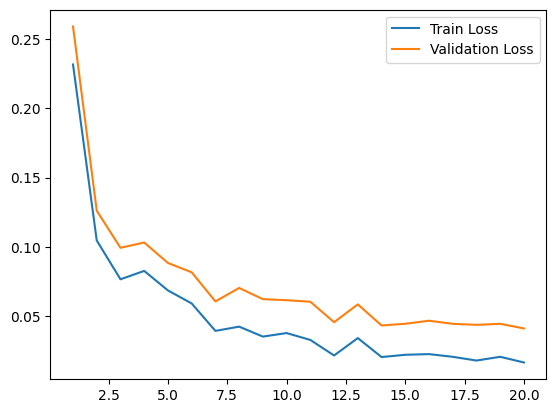

In [ ]:
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.legend()

# ax = plt.gca()
# ax.set_ylim([1E-1, 1])

plt.show()

#### Recreating the model

In [ ]:
model_recreate = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0,
).to(DEVICE)

/tmp/ipykernel_5289/1179507085.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


In [ ]:
# Optional: load best weights back into the model
if best_state is not None:
    model_recreate.load_state_dict(best_state)

In [ ]:
model

TimeSeriesViTRegressor(
  (spatial_encoder): SpatialCubeEncoder(
    (token_proj): Linear(in_features=4, out_features=128, bias=True)
    (conv): Sequential(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(32, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0, inplac

# Load model in from .pt

In [ ]:
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True)

In [ ]:
model_recreate.load_state_dict(checkpoint["model_state_dict"])
model_recreate.eval()

TimeSeriesViTRegressor(
  (spatial_encoder): SpatialCubeEncoder(
    (token_proj): Linear(in_features=4, out_features=128, bias=True)
    (conv): Sequential(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(32, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0, inplac

In [ ]:
cfg = checkpoint["config"]

model_recreate = TimeSeriesViTRegressor(
    cube_channels=cfg["CUBE_CHANNELS"],
    emb_dim=cfg["E"],
    grid_h=cfg["GRID_H"],
    grid_w=cfg["GRID_W"],
    seq_len=cfg["WINDOW"],
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0.1,
).to(DEVICE)

/tmp/ipykernel_5289/1179507085.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)


# Predict on predict and validation dataset

In [ ]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch_cubes, batch_embs, batch_y, batch_weights in val_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        all_preds.append(outputs.cpu())
        all_targets.append(batch_y.cpu())

# Concatenate all batches
preds = torch.cat(all_preds, dim=0)
y = torch.cat(all_targets, dim=0)

In [ ]:
model.eval()

predictions_0 = []
targets_0 = []

with torch.no_grad():
    for batch_cubes, batch_embs, batch_y, batch_weights in predict_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        predictions_0.append(outputs.cpu())
        targets_0.append(batch_y.cpu())

# Concatenate all batches
preds_all_0 = torch.cat(predictions_0, dim=0)
targets_all_0 = torch.cat(targets_0, dim=0)

In [ ]:
# Unnormalize
preds_unnorm = preds * y_std + y_mean
y_unnorm = y * y_std + y_mean

# print("Predictions:", preds_unnorm)
# print("Targets:    ", y_unnorm)

print(preds_unnorm.mean(), preds_unnorm.std())
print(y_unnorm.mean(), y_unnorm.std())

# Plot
x_plot = np.linspace(250, 350, 100)
y_plot = x_plot

tensor(296.9401) tensor(1.9401)
tensor(296.8897) tensor(2.0698)


In [ ]:
preds_unnorm

tensor([294.7507, 296.6019, 294.5652, 297.7119, 296.3309, 299.6476, 297.2599,
        299.9776, 296.0145, 293.5339, 297.4186, 294.5519, 295.4861, 295.6086,
        296.8364, 294.2731, 300.5819, 297.4433, 300.1646, 297.3561, 294.9128,
        292.4753, 295.0919, 299.4135, 296.9405, 299.0190, 299.8626, 299.6950,
        294.5245, 299.7116, 293.0045, 294.4109, 297.9915, 296.2491, 297.0178,
        293.4608, 297.9462, 296.2819, 296.4639, 300.4330, 297.1958, 296.2484,
        297.4729, 294.3038, 299.5190, 294.1743, 296.4955, 297.2093, 293.4543,
        299.1041, 294.2680, 298.8888, 295.3980, 296.1072, 296.6035, 296.7653,
        298.2326, 296.7818, 297.2308, 294.4108, 295.5540, 296.0214, 294.7556,
        298.2798, 295.5528, 296.5593, 298.0962, 297.5204, 298.4678, 299.8365,
        296.3847, 294.7503, 296.9663, 294.6712, 297.1630, 298.7138, 296.3089,
        300.5038, 296.6037, 300.4133, 299.7316, 299.5822, 298.3838, 295.3302,
        297.5019, 296.7379, 297.0543, 294.4309, 299.5239, 298.88

In [ ]:
y_unnorm

tensor([294.7170, 296.7508, 294.1633, 297.2566, 296.2380, 299.0067, 297.3387,
        299.4954, 295.8860, 293.7053, 296.6756, 294.9084, 295.2981, 295.4929,
        296.1458, 294.4641, 300.7088, 296.9969, 300.6336, 297.5335, 294.7581,
        290.7692, 295.2161, 299.1878, 297.4925, 298.6033, 299.6800, 299.9774,
        294.5735, 299.8270, 292.8440, 293.8591, 298.3025, 296.2415, 296.5901,
        292.8029, 297.2669, 296.4089, 296.5046, 300.4251, 297.0994, 296.2551,
        297.4788, 293.7121, 299.2186, 294.1736, 295.6023, 296.9490, 293.9001,
        299.6834, 293.8625, 299.2322, 295.4519, 295.7253, 296.5354, 296.9114,
        298.1180, 296.4670, 296.5251, 294.3889, 295.8826, 296.4055, 293.9070,
        297.9265, 295.6604, 296.8533, 298.2410, 297.7078, 298.0496, 300.3841,
        296.8260, 294.9255, 296.6277, 294.4333, 297.4480, 298.5247, 296.4294,
        300.9105, 296.9182, 300.3294, 299.8304, 299.1400, 298.5281, 294.7512,
        297.6702, 296.6892, 297.3181, 294.0197, 299.3177, 299.42

In [ ]:
y_unnorm.min()

tensor(290.9094)

In [ ]:
y_unnorm.max()

tensor(302.2914)

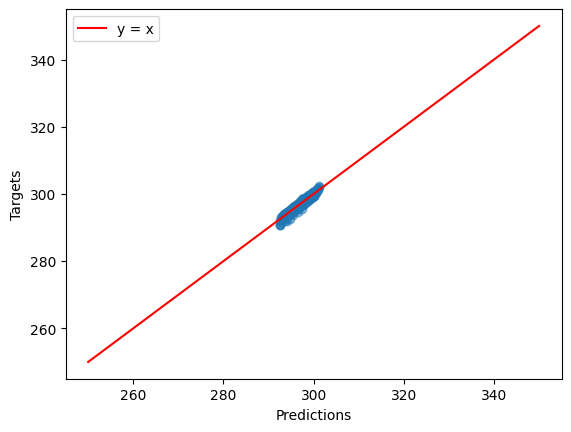

In [ ]:
plt.scatter(preds_unnorm.numpy(), y_unnorm.numpy(), alpha=0.5)
plt.plot(x_plot, y_plot, label='y = x', color='red')
plt.xlabel("Predictions")
plt.ylabel("Targets")
plt.legend()
plt.show()

In [ ]:
preds_fahrenheit = (preds_unnorm - 273.15) * 1.8 + 32
y_plot_fahrenheit = (y_unnorm - 273.15) * 1.8 + 32

In [ ]:
# Plot
x_plot_f = np.linspace(60, 90, 100)
y_plot_f = x_plot_f

In [ ]:
r2 = r2_score(y_plot_fahrenheit.numpy(), preds_fahrenheit.numpy())

In [ ]:
r2

0.9609590768814087

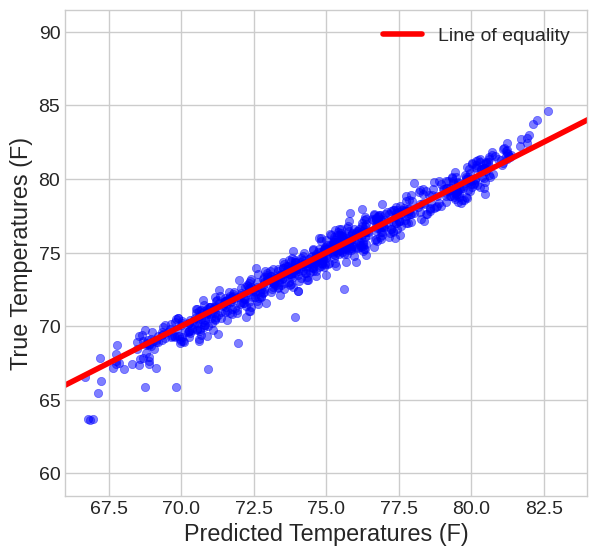

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6, 6))

plt.scatter(preds_fahrenheit.numpy(), y_plot_fahrenheit.numpy(), alpha=0.5, color='blue')
plt.plot(x_plot_f, y_plot_f, label=f'Line of equality', color='red')

plt.xlim(66, 84)

plt.xlabel("Predicted Temperatures (F)")
plt.ylabel("True Temperatures (F)")
plt.legend()
plt.show()

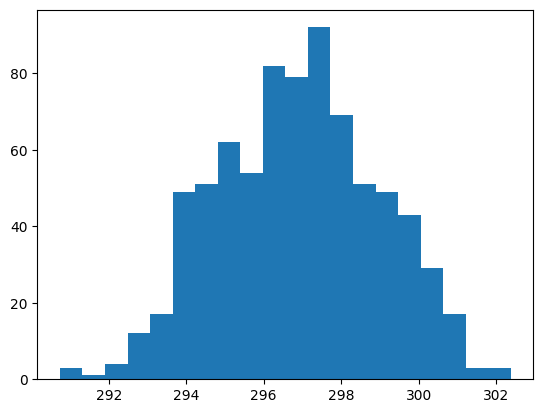

In [ ]:
plt.hist(y_unnorm.numpy(), bins=20)
plt.show()

In [ ]:
# Unnormalize
preds_unnorm_0 = preds_all_0 * y_std + y_mean
y_unnorm_0 = targets_all_0 * y_std + y_mean

# print("Predictions:", preds_unnorm)
# print("Targets:    ", y_unnorm)

print(preds_unnorm_0.mean(), preds_unnorm_0.std())
print(y_unnorm_0.mean(), y_unnorm_0.std())

# Plot
x_plot = np.linspace(250, 350, 100)
y_plot = x_plot

tensor(299.8298) tensor(1.1311)
tensor(308.1351) tensor(1.3377)


In [ ]:
preds_all_0.shape

torch.Size([5961])

In [ ]:
targets_all_0.shape

torch.Size([5961])

In [ ]:
x_plot_norm = np.linspace(-5, 5, 100)
y_plot_norm = x_plot_norm

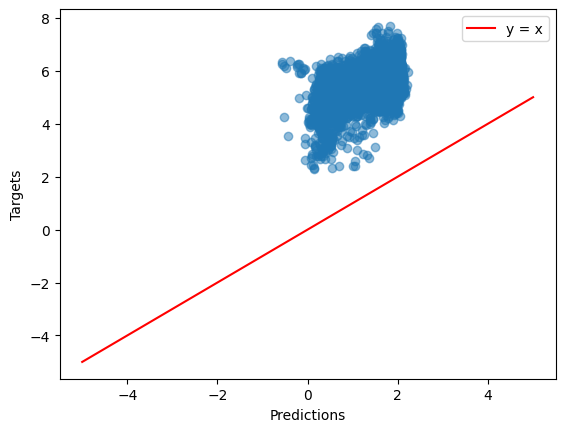

In [ ]:
plt.scatter(preds_all_0.numpy(), targets_all_0.numpy(), alpha=0.5)
plt.plot(x_plot_norm, y_plot_norm, label='y = x', color='red')
plt.xlabel("Predictions")
plt.ylabel("Targets")
plt.legend()
plt.show()

In [ ]:
len(preds_unnorm_0)

5961

In [ ]:
len(y_unnorm_0)

5961

In [ ]:
len(patches_0)

5961

In [ ]:
preds_unnorm_0[0]

tensor(298.5301)

In [ ]:
y_unnorm_0[0]

tensor(307.2919)

In [ ]:
data = []

In [ ]:
for i in range(len(patches_0)):
    center_value = patches_0[i][2][2]  # center of 5x5 array
    prediction = preds_unnorm_0[i].item()
    target = y_unnorm_0[i].item()

    data.append({
        "grid_id": center_value,
        "prediction": prediction,
        "target": target
    })

# Create DataFrame
grid_preds_df = pd.DataFrame(data)

In [ ]:
grid_preds_df

,grid_id,prediction,target
0,310,298.530090,307.291931
1,311,298.318481,307.196228
2,312,298.528870,307.011658
3,313,298.664886,306.868103
4,314,298.264862,306.700592
...,...,...,...
5956,7894,298.538666,306.348541
5957,7895,297.726105,306.502350
5958,8000,297.656830,306.888611
5959,8001,297.953888,306.522858


In [ ]:
grid_preds_df.to_csv("grid_preds.csv", index=False)

# Predict on before + Tree Analysis

In [ ]:
model.eval()

predictions_before = []

with torch.no_grad():
    for batch_cubes, batch_embs, _, batch_weights in before_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        predictions_before.append(outputs.cpu())

# Concatenate all batches
preds_all_before = torch.cat(predictions_before, dim=0)

In [ ]:
model.eval()

predictions_after = []

with torch.no_grad():
    for batch_cubes, batch_embs, _, batch_weights in after_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        predictions_after.append(outputs.cpu())

# Concatenate all batches
preds_all_after = torch.cat(predictions_after, dim=0)

In [ ]:
len(preds_all_before)

2187

In [ ]:
len(preds_all_after)

2187

In [ ]:
# Unnormalize
preds_before_unnorm = preds_all_before * y_std + y_mean
preds_after_unnorm = preds_all_after * y_std + y_mean

In [ ]:
preds_before_unnorm[100]

tensor(293.8107)

In [ ]:
preds_after_unnorm[100]

tensor(293.8104)

In [ ]:
len(valid_radii_ids)

2187

In [ ]:
valid_radii_ids[0]

np.int64(46)

In [ ]:
valid_radii_df = radii_df[radii_df["radii_id"].isin(valid_radii_ids)]

In [ ]:
valid_radii_df

,radii_id,SPP,DBH,grid_id
19,46,Gleditsia triacanthos,25,10242.0
20,48,Fraxinus pennsylvanica,10,10352.0
21,52,Crataegus x Lavallei,5,10353.0
22,1031,Ulmus pumila,20,6895.0
23,1034,Acer platanoides,13,10354.0
...,...,...,...,...
4385,108092,Gleditsia triacanthos,13,8954.0
4386,110208,Tilia cordata,19,6798.0
4387,110290,Pyrus calleryana,2,5706.0
4388,110291,Pyrus calleryana,2,5706.0


In [ ]:
valid_radii_df['diff'] = preds_before_unnorm - preds_after_unnorm

/tmp/ipykernel_9484/3188866114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_radii_df['diff'] = preds_before_unnorm - preds_after_unnorm


In [ ]:
valid_radii_df

,radii_id,SPP,DBH,grid_id,diff
19,46,Gleditsia triacanthos,25,10242.0,0.000000
20,48,Fraxinus pennsylvanica,10,10352.0,0.000061
21,52,Crataegus x Lavallei,5,10353.0,0.000031
22,1031,Ulmus pumila,20,6895.0,-0.000214
23,1034,Acer platanoides,13,10354.0,-0.000092
...,...,...,...,...,...
4385,108092,Gleditsia triacanthos,13,8954.0,-0.001831
4386,110208,Tilia cordata,19,6798.0,0.000854
4387,110290,Pyrus calleryana,2,5706.0,-0.000061
4388,110291,Pyrus calleryana,2,5706.0,0.000031


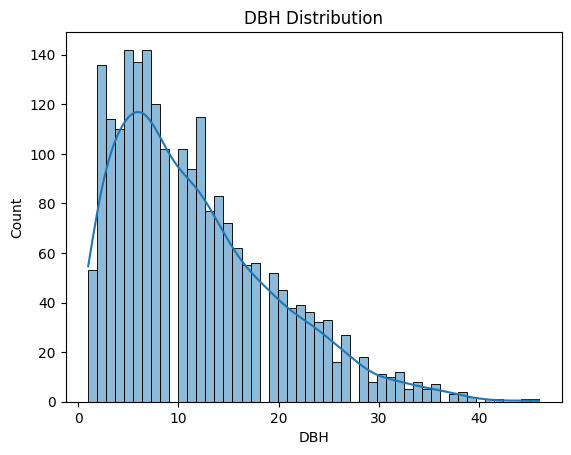

In [ ]:
# DBH distribution
sns.histplot(valid_radii_df['DBH'], bins=50, kde=True)
plt.title('DBH Distribution')
plt.show()

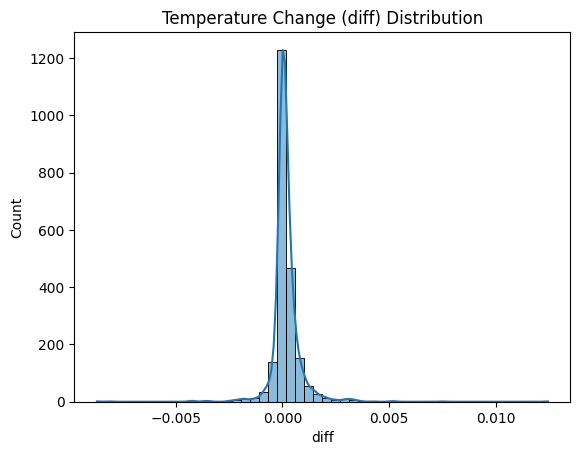

In [ ]:
# diff distribution
sns.histplot(valid_radii_df['diff'], bins=50, kde=True)
plt.title('Temperature Change (diff) Distribution')
plt.show()

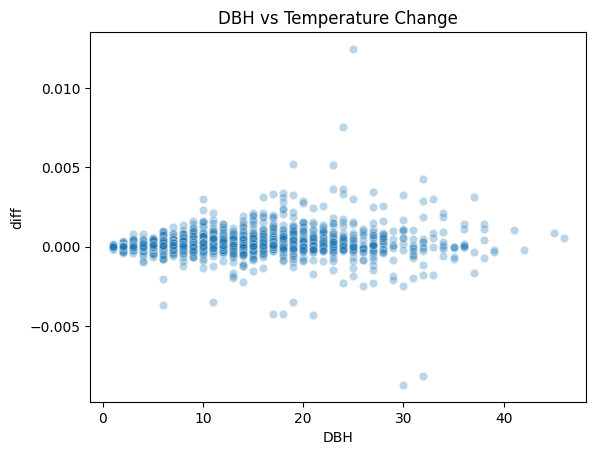

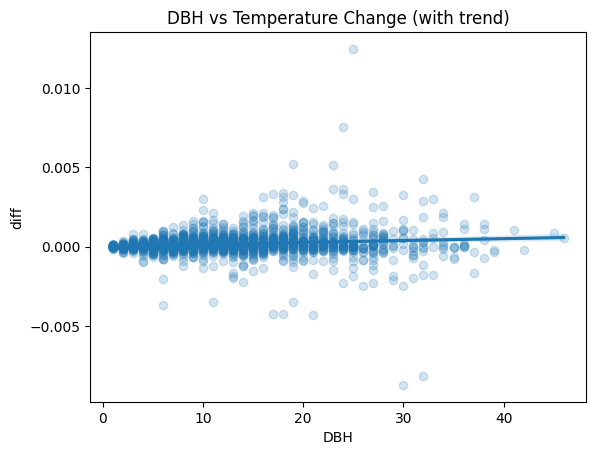

In [ ]:
sns.scatterplot(data=valid_radii_df, x='DBH', y='diff', alpha=0.3)
plt.title('DBH vs Temperature Change')
plt.show()

# With trend line
sns.regplot(data=valid_radii_df, x='DBH', y='diff', scatter_kws={'alpha':0.2})
plt.title('DBH vs Temperature Change (with trend)')
plt.show()

In [ ]:
top_species = valid_radii_df['SPP'].value_counts().head(10).index
df_top = valid_radii_df[valid_radii_df['SPP'].isin(top_species)]

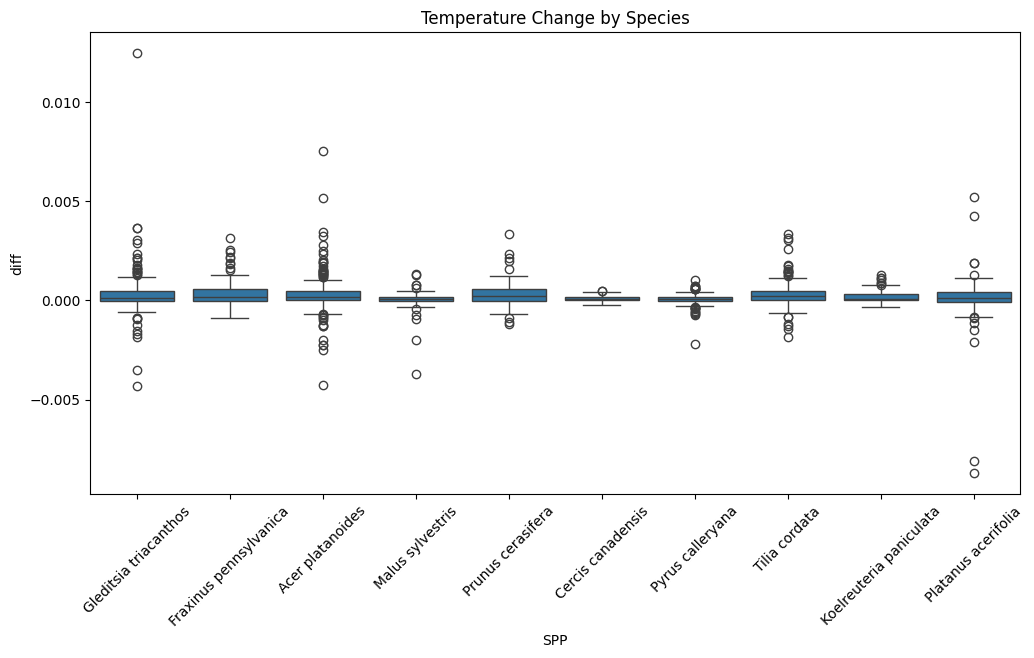

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='SPP', y='diff')
plt.xticks(rotation=45)
plt.title('Temperature Change by Species')
plt.show()

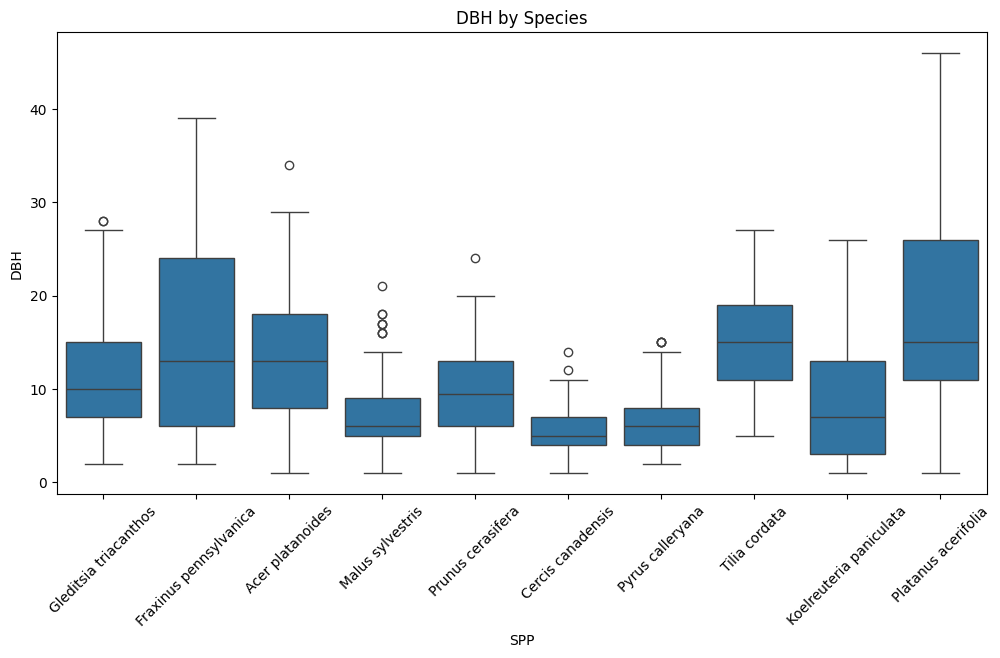

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='SPP', y='DBH')
plt.xticks(rotation=45)
plt.title('DBH by Species')
plt.show()

In [ ]:
print(valid_radii_df[['DBH', 'diff']].corr())

           DBH      diff
DBH   1.000000  0.126115
diff  0.126115  1.000000


In [ ]:
species_summary = valid_radii_df.groupby('SPP').agg({
    'DBH': ['mean', 'median', 'count'],
    'diff': ['mean', 'median']
}).sort_values(('diff', 'mean'), ascending=False)

print(species_summary.head(10))

                               DBH                   diff          
                              mean median count      mean    median
SPP                                                                
Prunus cerasifera         9.500000    9.5    78  0.000332  0.000198
Fraxinus pennsylvanica   15.896226   13.0   106  0.000324  0.000153
Tilia cordata            15.052910   15.0   189  0.000286  0.000214
Gleditsia triacanthos    11.321033   10.0   271  0.000272  0.000092
Acer platanoides         12.752542   13.0   295  0.000272  0.000153
Zelkova serrata           8.689189    8.5    74  0.000230  0.000092
Fraxinus americana       12.676923    7.0    65  0.000194  0.000031
Koelreuteria paniculata   8.322581    7.0    93  0.000189  0.000061
Ulmus pumila             17.535714   18.5    56  0.000183  0.000000
Acer campestre            5.611111    6.5    36  0.000168  0.000061


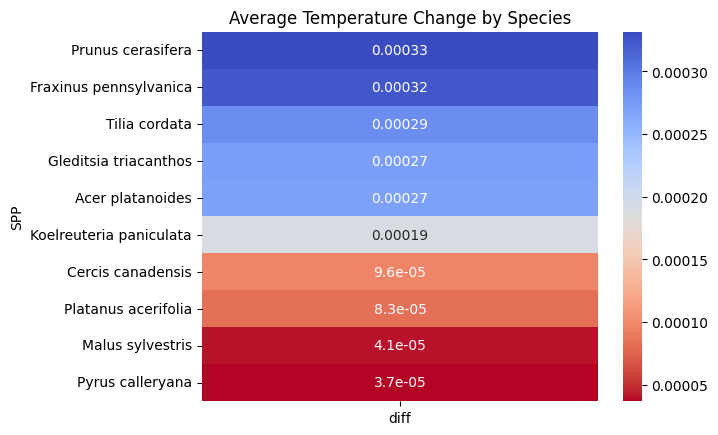

In [ ]:
pivot = df_top.pivot_table(values='diff', index='SPP', aggfunc='mean')

sorted_pivot = pivot.sort_values(by='diff', ascending=False)

sns.heatmap(sorted_pivot, annot=True, cmap='coolwarm_r')
plt.title('Average Temperature Change by Species')
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Treat species as categorical
model_tree = smf.ols('diff ~ DBH + C(SPP)', data=valid_radii_df).fit()

print(model_tree.summary())

                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.463
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.95e-08
Time:                        01:09:53   Log-Likelihood:                 12710.
No. Observations:                2187   AIC:                        -2.537e+04
Df Residuals:                    2162   BIC:                        -2.523e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

<Axes: >

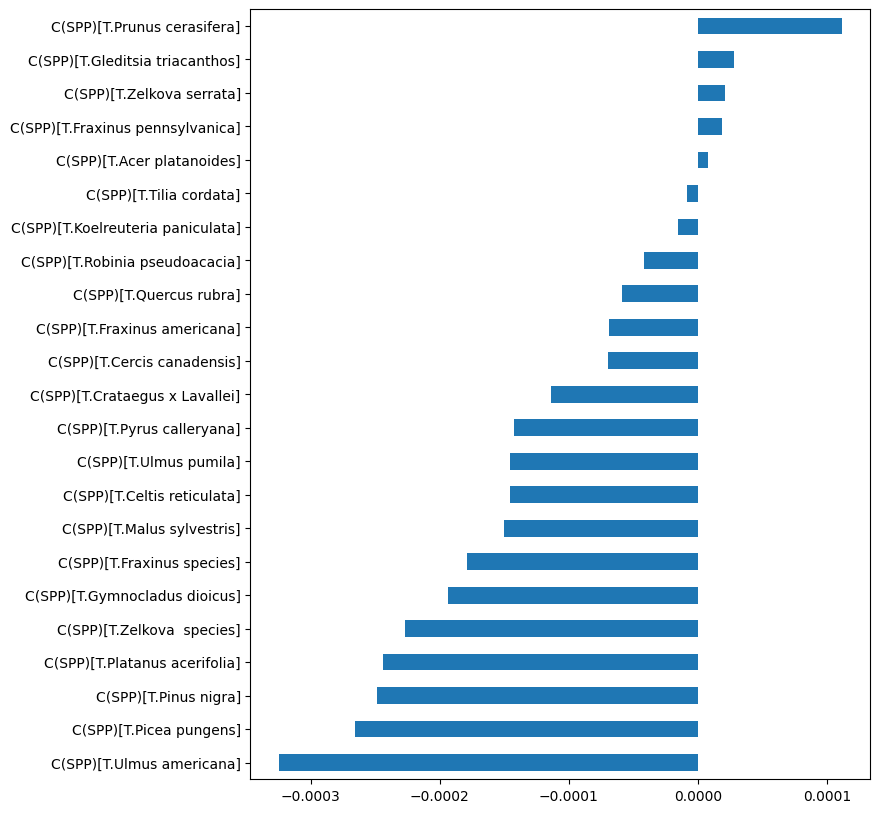

In [ ]:
coefs = model_tree.params.filter(like='C(SPP)')
coefs = coefs.sort_values()

coefs.plot(kind='barh', figsize=(8,10))

In [ ]:
valid_radii_df_copy = valid_radii_df.copy()

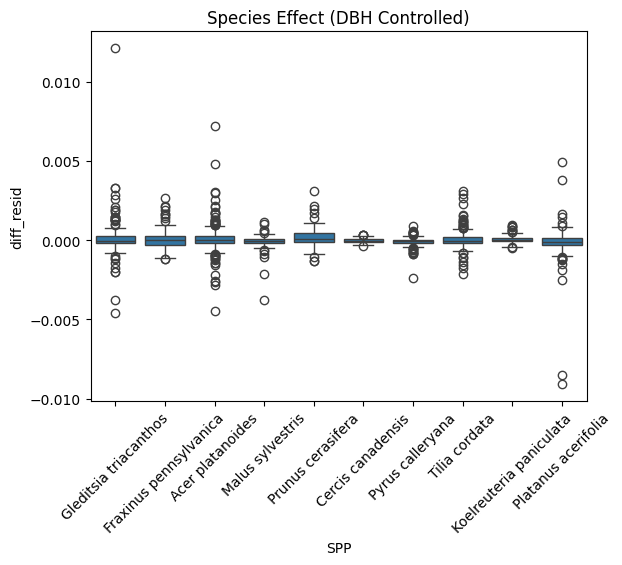

In [ ]:
model_dbh = smf.ols('diff ~ DBH', data=valid_radii_df_copy).fit()

valid_radii_df_copy['diff_resid'] = model_dbh.resid
top_species = valid_radii_df_copy['SPP'].value_counts().head(10).index
df_top = valid_radii_df_copy[valid_radii_df_copy['SPP'].isin(top_species)]

sns.boxplot(data=df_top, x='SPP', y='diff_resid')
plt.xticks(rotation=45)
plt.title('Species Effect (DBH Controlled)')
plt.show()

# Shap Analysis

In [ ]:
def collect_samples(loader, n_samples):
    cubes = []
    embs = []

    for x_cube, x_emb, _, _ in loader:
        cubes.append(x_cube)
        embs.append(x_emb)

        if sum(x.shape[0] for x in cubes) >= n_samples:
            break

    cubes = torch.cat(cubes, dim=0)[:n_samples]
    embs = torch.cat(embs, dim=0)[:n_samples]

    return cubes.to(device), embs.to(device)

In [ ]:
# Select small subsets (important for SHAP performance)
N_BACKGROUND = 50
N_SAMPLES = 100

TOTAL = N_BACKGROUND + N_SAMPLES

x_cube_all, x_emb_all = collect_samples(train_loader, TOTAL)

background_cube = x_cube_all[:N_BACKGROUND]
background_emb = x_emb_all[:N_BACKGROUND]

test_cube = x_cube_all[N_BACKGROUND:TOTAL]
test_emb = x_emb_all[N_BACKGROUND:TOTAL]

In [ ]:
cube_baseline = background_cube.mean(dim=0, keepdim=True)  # [1, T, C, H, W]

In [ ]:
print("x_cube_sample:", test_cube.shape)
print("background_cube:", background_cube.shape)
print("test_cube:", test_cube.shape)

x_cube_sample: torch.Size([100, 100, 4, 5, 5])
background_cube: torch.Size([50, 100, 4, 5, 5])
test_cube: torch.Size([100, 100, 4, 5, 5])


In [ ]:
class RasterWrapper(torch.nn.Module):
    def __init__(self, model, x_cube, x_emb, baseline):
        super().__init__()
        self.model = model
        self.x_cube = x_cube
        self.x_emb = x_emb
        self.baseline = baseline

    def forward(self, band_mask):
        band_mask = torch.tensor(band_mask, dtype=torch.float32, device=self.x_cube.device)

        outputs = []

        for i in range(band_mask.shape[0]):
            x_cube = self.x_cube[i % len(self.x_cube)].clone()
            x_emb = self.x_emb[i % len(self.x_emb)].unsqueeze(0)

            mask = band_mask[i]

            for j in range(4):
                x_cube[:, j, :, :] = (
                    mask[j] * x_cube[:, j, :, :]
                    + (1 - mask[j]) * self.baseline[:, j, :, :]
                )

            out = self.model(x_cube.unsqueeze(0), x_emb)
            outputs.append(out.item())

        return np.array(outputs)

In [ ]:
raster_model = RasterWrapper(model, test_cube, test_emb, cube_baseline)

explainer = shap.KernelExplainer(
    raster_model,
    np.zeros((N_BACKGROUND, 4))  # baseline = all features ON
)

shap_values = explainer.shap_values(
    np.ones((N_SAMPLES, 4)),
    nsamples=200
)

Provided model function fails when applied to the provided data set.


RuntimeError: The size of tensor a (100) must match the size of tensor b (4) at non-singleton dimension 1

In [ ]:
background_mask = np.ones((N_BACKGROUND, 4))
explainer = shap.KernelExplainer(raster_model, background_mask)

In [ ]:
shap_values = explainer.shap_values(
    np.zeros((N_SAMPLES, 4)),
    nsamples=200
)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
feature_names_raster = ['Blue', 'Green', 'Red', 'NIR']

importance_raster = np.mean(np.abs(shap_values), axis=0)

for name, val in zip(feature_names_raster, importance_raster):
    print(f"{name}: {val:.6f}")

Blue: 0.207590
Green: 0.007782
Red: 0.139422
NIR: 0.210510


In [ ]:
shap_values

array([[-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.00778223,  0.13942192,  0.21050992],
       [-0.20758992,  0.

In [ ]:
X_explain = np.ones((N_SAMPLES, 4))

/tmp/ipykernel_9484/2596850070.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


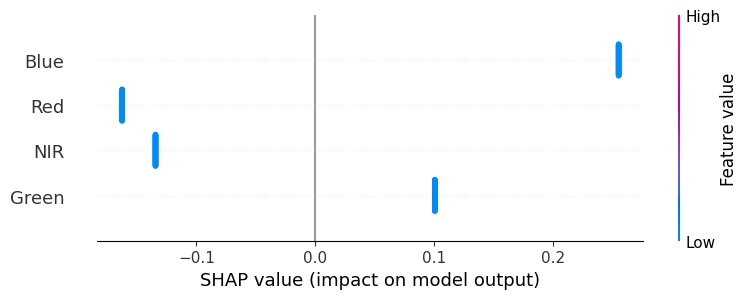

In [ ]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_raster,
    plot_type="dot"   # this is the classic beeswarm
)

In [ ]:
print(np.unique(shap_values, axis=0).shape)

(1, 4)


In [ ]:
mask_all_on = np.ones((10, 4))
mask_blue_off = np.array([[0,1,1,1]] * 10)

out1 = raster_model(mask_all_on)
out2 = raster_model(mask_blue_off)

print("diff:", np.abs(out1 - out2).mean())

diff: 0.20662439


## Manually Improve tree visual

In [41]:
data = """
                               DBH                   diff
                              mean median count      mean    median
SPP
Prunus cerasifera         9.500000    9.5    78  0.000332  0.000198
Fraxinus pennsylvanica   15.896226   13.0   106  0.000324  0.000153
Tilia cordata            15.052910   15.0   189  0.000286  0.000214
Gleditsia triacanthos    11.321033   10.0   271  0.000272  0.000092
Acer platanoides         12.752542   13.0   295  0.000272  0.000153
Zelkova serrata           8.689189    8.5    74  0.000230  0.000092
Fraxinus americana       12.676923    7.0    65  0.000194  0.000031
Koelreuteria paniculata   8.322581    7.0    93  0.000189  0.000061
Ulmus pumila             17.535714   18.5    56  0.000183  0.000000
Acer campestre            5.611111    6.5    36  0.000168  0.000061
"""

In [42]:
# Use StringIO to simulate reading from a file
data_io = StringIO(data)

# Read the data using fixed-width formatting
df = pd.read_fwf(data_io, skiprows=1)

# Ensure the index is treated as strings before applying .str.strip()
df.index = df.index.astype(str).str.strip()  # Convert to string and strip extra spaces

# Set the index name
df.index.name = 'SPP'

# Display the DataFrame
print(df)

                  Unnamed: 0        DBH Unnamed: 2 Unnamed: 3      diff  \
SPP                                                                       
0                        NaN       mean     median      count      mean   
1                        SPP        NaN        NaN        NaN       NaN   
2          Prunus cerasifera   9.500000        9.5         78  0.000332   
3     Fraxinus pennsylvanica  15.896226       13.0        106  0.000324   
4              Tilia cordata  15.052910       15.0        189  0.000286   
5      Gleditsia triacanthos  11.321033       10.0        271  0.000272   
6           Acer platanoides  12.752542       13.0        295  0.000272   
7            Zelkova serrata   8.689189        8.5         74  0.000230   
8         Fraxinus americana  12.676923        7.0         65  0.000194   
9    Koelreuteria paniculata   8.322581        7.0         93  0.000189   
10              Ulmus pumila  17.535714       18.5         56  0.000183   
11            Acer campes

In [43]:
df

,Unnamed: 0,DBH,Unnamed: 2,Unnamed: 3,diff,Unnamed: 5
SPP,,,,,,
0,NaN,mean,median,count,mean,median
1,SPP,NaN,NaN,NaN,NaN,NaN
2,Prunus cerasifera,9.500000,9.5,78,0.000332,0.000198
3,Fraxinus pennsylvanica,15.896226,13.0,106,0.000324,0.000153
4,Tilia cordata,15.052910,15.0,189,0.000286,0.000214
5,Gleditsia triacanthos,11.321033,10.0,271,0.000272,0.000092
6,Acer platanoides,12.752542,13.0,295,0.000272,0.000153
7,Zelkova serrata,8.689189,8.5,74,0.000230,0.000092
8,Fraxinus americana,12.676923,7.0,65,0.000194,0.000031


In [44]:
df.columns

Index(['Unnamed: 0', 'DBH', 'Unnamed: 2', 'Unnamed: 3', 'diff', 'Unnamed: 5'], dtype='object')

In [45]:
trees = df['Unnamed: 0'][2:12]

In [46]:
trees = trees.values

In [47]:
trees

array(['Prunus cerasifera', 'Fraxinus pennsylvanica', 'Tilia cordata',
       'Gleditsia triacanthos', 'Acer platanoides', 'Zelkova serrata',
       'Fraxinus americana', 'Koelreuteria paniculata', 'Ulmus pumila',
       'Acer campestre'], dtype=object)

In [48]:
diff = df['diff'][2:12].values

In [49]:
diff

array(['0.000332', '0.000324', '0.000286', '0.000272', '0.000272',
       '0.000230', '0.000194', '0.000189', '0.000183', '0.000168'],
      dtype=object)

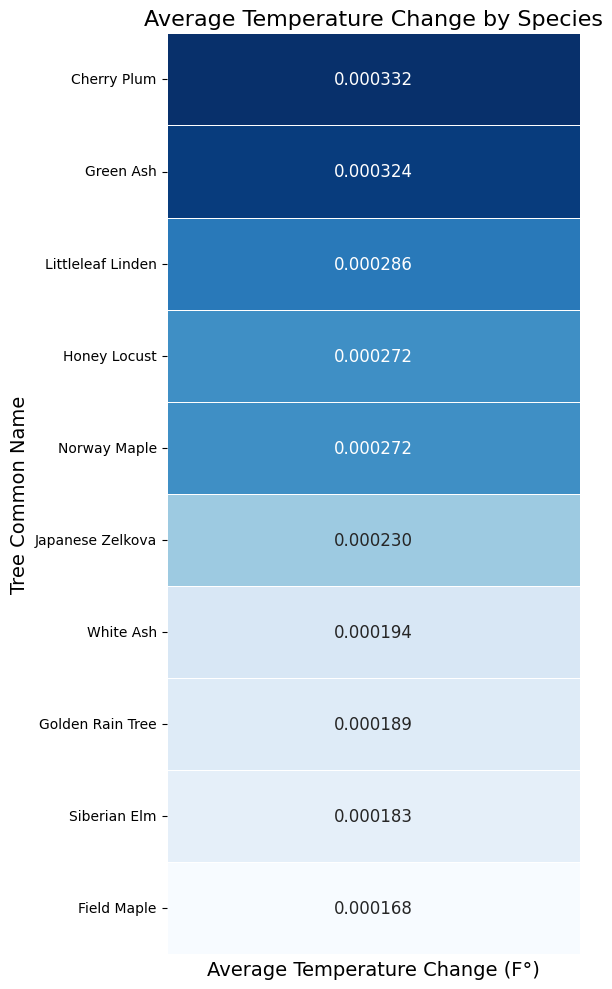

In [78]:
# Convert diff to numeric values
diff_values = np.array(diff, dtype=float)

# Map scientific names to common names
tree_names = [
    "Cherry Plum", "Green Ash", "Littleleaf Linden", "Honey Locust",
    "Norway Maple", "Japanese Zelkova", "White Ash", "Golden Rain Tree",
    "Siberian Elm", "Field Maple"
]

# Reshape data for vertical plotting
heatmap_data = diff_values.reshape(-1, 1)  # 10 rows and 1 column

# Plotting
plt.figure(figsize=(6, 10))  # Adjust figure size for vertical plot
sns.heatmap(heatmap_data, annot=True, fmt=".6f", cmap="Blues", cbar=False,
            yticklabels=tree_names, xticklabels=[], linewidths=0.5, annot_kws={"size": 12})

# Adding titles and labels
plt.title('Average Temperature Change by Species', fontsize=16)
plt.ylabel('Tree Common Name', fontsize=14)
plt.xlabel('Average Temperature Change (F°)', fontsize=14)
plt.xticks(rotation=0, fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

## Manually improve y=x visual

In [53]:
preds_unnorm = torch.tensor([294.7507, 296.6019, 294.5652, 297.7119, 296.3309, 299.6476, 297.2599,
        299.9776, 296.0145, 293.5339, 297.4186, 294.5519, 295.4861, 295.6086,
        296.8364, 294.2731, 300.5819, 297.4433, 300.1646, 297.3561, 294.9128,
        292.4753, 295.0919, 299.4135, 296.9405, 299.0190, 299.8626, 299.6950,
        294.5245, 299.7116, 293.0045, 294.4109, 297.9915, 296.2491, 297.0178,
        293.4608, 297.9462, 296.2819, 296.4639, 300.4330, 297.1958, 296.2484,
        297.4729, 294.3038, 299.5190, 294.1743, 296.4955, 297.2093, 293.4543,
        299.1041, 294.2680, 298.8888, 295.3980, 296.1072, 296.6035, 296.7653,
        298.2326, 296.7818, 297.2308, 294.4108, 295.5540, 296.0214, 294.7556,
        298.2798, 295.5528, 296.5593, 298.0962, 297.5204, 298.4678, 299.8365,
        296.3847, 294.7503, 296.9663, 294.6712, 297.1630, 298.7138, 296.3089,
        300.5038, 296.6037, 300.4133, 299.7316, 299.5822, 298.3838, 295.3302,
        297.5019, 296.7379, 297.0543, 294.4309, 299.5239, 298.8886, 294.6006,
        300.0857, 293.3101, 295.2346, 295.3802, 299.2053, 293.5810, 293.1740,
        297.3379, 300.1039, 299.2092, 298.5229, 295.5670, 294.6164, 299.1379,
        292.5794, 298.0905, 298.2389, 300.3297, 300.2678, 297.5212, 299.4913,
        294.1200, 293.5965, 294.9438, 299.5648, 297.6114, 299.7213, 296.7238,
        297.4135, 296.1410, 297.6916, 298.5713, 299.1659, 296.3541, 298.0750,
        296.5002, 298.5743, 296.6191, 297.2762, 297.6244, 294.8992, 296.0224,
        296.4073, 294.6002, 297.0670, 299.7405, 295.0194, 299.3399, 294.7008,
        294.0616, 295.7085, 298.3748, 299.6836, 298.1008, 296.0443, 293.6432,
        294.7923, 301.2943, 297.1941, 296.4027, 298.0688, 298.8130, 298.0378,
        296.7447, 298.1469, 296.2324, 298.1201, 295.0693, 294.5768, 299.5408,
        296.9343, 293.6283, 298.4067, 300.0537, 294.6967, 295.0175, 295.4644,
        298.4882, 297.8055, 295.1065, 297.1845, 297.7071, 297.5224, 295.8727,
        294.3928, 298.8297, 295.7058, 298.8629, 295.3778, 296.1621, 297.3619,
        299.9836, 293.9102, 297.7313, 297.4741, 297.5670, 294.9366, 297.1759,
        296.5879, 293.6383, 297.0233, 296.6589, 300.3842, 298.7970, 297.7484,
        295.2019, 295.1942, 295.8504, 298.1070, 296.0696, 297.3343, 297.6083,
        297.0779, 298.6916, 294.7061, 299.5597, 296.3508, 297.4706, 297.7589,
        295.7502, 293.6747, 297.6173, 296.9476, 296.8565, 296.4911, 300.5001,
        296.9590, 293.7014, 298.6086, 293.6461, 296.1596, 297.1188, 293.7431,
        295.4135, 295.4780, 294.9102, 297.9886, 299.8043, 297.8342, 296.9083,
        299.6050, 299.5560, 297.0341, 296.4593, 294.1633, 296.7134, 297.1864,
        299.8774, 296.4457, 293.0046, 295.6819, 298.5512, 294.3384, 297.5413,
        294.0111, 297.6596, 294.6622, 294.9673, 298.8925, 297.0343, 294.7280,
        296.1896, 299.4577, 293.4722, 294.8628, 296.5476, 293.8123, 300.7623,
        297.7492, 294.7803, 293.9583, 298.4516, 297.2069, 295.8787, 298.5242,
        297.1819, 293.7771, 294.4133, 300.0968, 293.5688, 297.7760, 300.0222,
        297.9463, 299.5521, 293.7176, 294.6096, 298.0879, 297.6516, 296.4531,
        299.6537, 298.0399, 300.9933, 297.1665, 300.4946, 297.9964, 296.0726,
        295.9960, 295.5714, 297.0491, 300.0613, 293.8190, 296.6695, 298.9428,
        295.0955, 294.5691, 295.7210, 296.3853, 297.5792, 294.9802, 296.6474,
        299.4610, 298.0168, 295.7363, 297.4600, 295.3996, 297.5168, 295.9746,
        297.2411, 297.1563, 299.5256, 295.1132, 297.2874, 296.1183, 300.1546,
        297.5360, 296.3634, 296.2160, 299.0366, 296.1554, 300.8787, 294.8153,
        297.1078, 296.8858, 296.7762, 300.1650, 297.9828, 295.6076, 296.8494,
        296.4464, 295.6685, 297.7400, 298.1704, 296.0308, 294.9142, 298.0251,
        297.3441, 295.2446, 295.5033, 297.9606, 295.7980, 296.8477, 293.4062,
        301.0867, 297.7698, 299.0137, 296.9111, 299.4541, 295.2271, 297.3490,
        297.7765, 297.6196, 293.7717, 297.1818, 295.8363, 299.5132, 300.5380,
        296.8820, 299.8406, 294.3110, 295.8570, 298.0497, 295.5246, 296.8236,
        299.9879, 294.9993, 296.5039, 297.7931, 300.0815, 298.5635, 297.0372,
        297.2875, 297.2456, 295.1347, 296.0266, 297.5398, 293.5122, 297.8319,
        299.3787, 294.8234, 297.2476, 299.7699, 295.2408, 292.7068, 295.6629,
        297.7418, 300.2245, 297.2420, 299.7912, 296.2285, 299.5057, 294.4713,
        295.7811, 299.9091, 295.2336, 299.6179, 296.9087, 298.6679, 295.9690,
        295.4603, 297.3111, 298.3701, 299.0649, 296.7255, 296.7870, 298.9558,
        300.4229, 298.3925, 296.7154, 297.5239, 297.9934, 296.7928, 300.2096,
        299.0546, 297.3701, 297.0881, 299.4336, 295.5641, 296.6752, 297.7224,
        297.2809, 297.3929, 299.6538, 294.8758, 300.9228, 297.0115, 294.1470,
        295.1328, 297.7914, 298.7171, 298.1473, 296.3312, 298.4358, 293.6812,
        294.7197, 293.9037, 296.9352, 296.5631, 296.2399, 297.1321, 296.9532,
        296.4916, 300.1656, 298.4278, 295.9075, 296.1221, 294.2315, 294.0403,
        297.4035, 297.0404, 296.5224, 299.5020, 296.4365, 296.4473, 298.2498,
        294.3897, 300.8895, 298.6735, 298.9193, 294.6365, 295.6960, 299.8002,
        298.2797, 294.8460, 294.4368, 296.2061, 294.0626, 296.7852, 299.1583,
        296.4608, 295.1283, 299.2381, 297.4897, 297.3786, 295.0814, 294.6461,
        296.8152, 296.2914, 294.2015, 296.1078, 297.0053, 297.9200, 294.2405,
        296.0155, 297.5692, 294.6060, 295.2283, 300.0112, 297.3456, 295.7384,
        297.3344, 294.2711, 296.3999, 293.8871, 297.2637, 296.7962, 294.1617,
        299.3282, 298.5613, 300.4791, 294.1920, 296.3267, 295.2780, 299.7372,
        294.8161, 297.6534, 293.4237, 297.1714, 294.4976, 299.7589, 300.5674,
        297.7322, 299.2420, 299.5847, 298.3414, 298.8369, 296.2178, 299.5815,
        294.7778, 295.4715, 296.9297, 296.8731, 297.2031, 296.3614, 298.3275,
        295.8221, 295.5801, 295.0924, 297.0412, 299.9297, 295.1926, 294.9890,
        298.0285, 297.3012, 297.4872, 298.4454, 295.1455, 296.0381, 292.9600,
        299.5180, 297.4716, 296.7519, 299.3435, 296.1806, 294.9251, 296.1093,
        300.0642, 296.4698, 299.7862, 296.7103, 297.3063, 300.4940, 294.0807,
        298.6458, 296.7876, 295.2935, 297.0698, 298.3859, 295.3464, 297.0068,
        294.4165, 300.7569, 297.1435, 297.9938, 297.3145, 294.7646, 293.7715,
        293.5870, 298.3569, 295.9051, 298.2701, 294.1749, 297.4444, 293.9511,
        297.7240, 297.3318, 293.0762, 297.6752, 300.0562, 296.4662, 297.7810,
        297.4611, 293.5255, 293.5765, 298.6037, 294.9070, 294.6262, 296.9489,
        295.4363, 300.1796, 299.3375, 295.9817, 296.4479, 299.0882, 296.2646,
        298.3287, 296.6477, 295.7881, 293.6489, 297.7086, 297.6715, 294.6913,
        295.5450, 299.3403, 294.8502, 296.6186, 299.4090, 300.0594, 299.7621,
        298.8298, 298.0446, 294.6737, 299.8033, 294.2237, 292.5161, 297.4819,
        297.2828, 296.9039, 298.6322, 299.8932, 295.3236, 298.3879, 298.0159,
        295.5467, 296.9298, 292.7316, 298.3181, 295.9134, 296.6001, 295.9311,
        297.7782, 296.3508, 295.1714, 300.1435, 295.8568, 298.0916, 297.8065,
        297.7837, 295.3489, 299.7269, 293.6471, 299.7718, 297.6528, 297.7560,
        293.8987, 296.6857, 296.6921, 299.4704, 297.2138, 297.9294, 298.9625,
        298.3586, 299.3762, 297.2274, 294.4627, 294.9040, 297.4782, 300.0683,
        297.7971, 295.5031, 295.2084, 297.3454, 298.5442, 300.5210, 294.9618,
        299.8842, 298.0179, 295.4084, 295.2540, 298.6272, 296.8380, 292.6769,
        299.0291, 296.1728, 297.9988, 299.3026, 296.2441, 294.5614, 298.6628,
        294.7459, 293.0370, 296.6389, 296.1346, 297.6979, 298.4521, 292.4278,
        296.3662, 295.7740, 298.2115, 299.6914, 296.5692, 296.9812, 300.4814,
        296.8436, 296.0017, 298.5587, 297.3181, 295.2514, 294.2508, 295.9032,
        295.9811, 294.9172, 296.3576, 297.4414, 298.0845, 296.4384, 297.2839,
        295.6343, 295.5511, 295.5982, 296.9592, 294.6360, 300.0062, 296.9197,
        298.4705, 295.1382, 296.2069, 297.1775, 296.3577, 293.6149, 297.2499,
        294.5683, 300.4460, 297.7963, 294.1447, 299.9570, 295.5917, 293.0052,
        298.1022, 298.6225, 294.7267, 297.0316, 294.4202, 299.2790, 299.1038,
        298.3268, 294.4812, 296.9696, 296.3156, 299.9049, 295.0954, 293.8953,
        299.9019, 296.9974, 298.9225, 294.5443, 298.2816, 297.2016, 300.2283,
        295.1487, 295.6702, 294.8208, 299.9175, 297.7397, 294.2673, 296.3129,
        297.5144, 299.5436, 295.8557, 297.3867, 295.8568, 298.6028, 300.0981,
        295.1863, 298.1247, 299.8365, 296.3177, 299.4365, 299.3505, 296.4422])

In [54]:
y_unnorm = torch.tensor([294.7170, 296.7508, 294.1633, 297.2566, 296.2380, 299.0067, 297.3387,
        299.4954, 295.8860, 293.7053, 296.6756, 294.9084, 295.2981, 295.4929,
        296.1458, 294.4641, 300.7088, 296.9969, 300.6336, 297.5335, 294.7581,
        290.7692, 295.2161, 299.1878, 297.4925, 298.6033, 299.6800, 299.9774,
        294.5735, 299.8270, 292.8440, 293.8591, 298.3025, 296.2415, 296.5901,
        292.8029, 297.2669, 296.4089, 296.5046, 300.4251, 297.0994, 296.2551,
        297.4788, 293.7121, 299.2186, 294.1736, 295.6023, 296.9490, 293.9001,
        299.6834, 293.8625, 299.2322, 295.4519, 295.7253, 296.5354, 296.9114,
        298.1180, 296.4670, 296.5251, 294.3889, 295.8826, 296.4055, 293.9070,
        297.9265, 295.6604, 296.8533, 298.2410, 297.7078, 298.0496, 300.3841,
        296.8260, 294.9255, 296.6277, 294.4333, 297.4480, 298.5247, 296.4294,
        300.9105, 296.9182, 300.3294, 299.8304, 299.1400, 298.5281, 294.7512,
        297.6702, 296.6892, 297.3181, 294.0197, 299.3177, 299.4236, 294.6589,
        299.6937, 292.8200, 295.3596, 295.1033, 299.7381, 293.5549, 292.6560,
        297.1951, 300.1038, 298.9007, 298.6546, 295.6912, 294.0847, 298.7469,
        290.7726, 297.8069, 298.5076, 300.5755, 300.6952, 297.5164, 299.1536,
        293.8864, 293.2644, 295.2434, 299.7176, 297.2293, 299.1263, 296.3098,
        297.1575, 296.1799, 297.3284, 298.4085, 298.7776, 296.2209, 298.4632,
        296.3542, 298.1453, 296.5935, 297.9436, 297.8479, 294.9905, 295.8997,
        296.2654, 294.8196, 297.0960, 300.2747, 294.8093, 298.9588, 295.0452,
        294.3547, 295.2297, 298.1487, 299.0272, 298.8870, 296.0945, 292.9602,
        294.9836, 302.3768, 297.6087, 295.7458, 297.6189, 299.3314, 298.3982,
        296.6209, 297.9915, 295.6775, 298.0017, 295.0110, 294.4778, 299.3655,
        297.5745, 293.7395, 298.5760, 299.4920, 294.2453, 294.5837, 295.3049,
        298.6443, 297.3592, 295.3220, 296.8362, 297.5984, 297.2259, 296.3303,
        294.0608, 298.5623, 295.7322, 298.2991, 296.0022, 296.0500, 297.6189,
        300.5516, 293.9685, 298.0393, 297.2840, 297.5506, 294.6248, 297.2566,
        296.6106, 293.5788, 297.2395, 296.5388, 300.5345, 298.7640, 297.1096,
        295.4075, 295.2126, 295.5442, 297.7112, 296.0706, 297.0618, 296.6892,
        297.1746, 298.9930, 294.3171, 298.9554, 296.3748, 297.3079, 297.1575,
        295.3152, 293.7737, 297.2566, 297.0515, 296.7234, 296.4021, 300.7977,
        296.6038, 294.0368, 298.6956, 293.1037, 295.4519, 297.7556, 293.3943,
        295.6912, 295.7458, 294.5085, 297.8684, 299.6253, 297.8172, 297.5813,
        299.4373, 299.6766, 296.9353, 296.6721, 291.9758, 296.7952, 297.4378,
        299.6253, 296.5730, 293.2165, 295.3459, 298.6136, 294.0403, 297.7762,
        294.0266, 297.9129, 294.7444, 294.6829, 298.9144, 297.1746, 294.7717,
        296.0295, 299.8885, 293.0217, 294.1360, 296.0706, 293.6540, 301.3412,
        297.3455, 294.2761, 293.8249, 297.7010, 297.5232, 295.1375, 298.7059,
        297.5335, 293.6574, 294.0642, 300.4217, 291.9792, 297.8035, 299.8782,
        298.5110, 299.2391, 293.6950, 293.7805, 297.5642, 297.8479, 296.4363,
        299.4852, 298.2683, 301.8949, 297.3387, 301.1703, 298.3572, 295.8210,
        295.9783, 295.9749, 296.9661, 299.8680, 293.9035, 295.9919, 298.4871,
        294.7991, 294.3786, 295.9202, 296.0671, 296.8977, 295.6160, 296.2688,
        299.7415, 297.4788, 295.1067, 297.1370, 295.5134, 297.1233, 296.1492,
        297.0584, 297.1643, 299.5775, 294.9905, 297.2805, 295.7014, 300.5687,
        297.2874, 296.7166, 296.0637, 298.6922, 296.1560, 301.3446, 294.7375,
        297.3181, 296.8533, 296.4875, 299.9534, 297.5266, 295.7219, 296.9729,
        294.6248, 295.6023, 297.2771, 298.4803, 295.8484, 295.3733, 298.2137,
        297.6736, 295.3972, 294.6248, 298.4734, 295.6775, 296.6961, 293.4113,
        302.0487, 297.9471, 299.2117, 296.9148, 299.8509, 294.9050, 297.1746,
        297.8274, 297.7693, 292.6662, 297.3694, 296.0398, 300.0765, 300.6815,
        296.7679, 300.4354, 293.6472, 295.9202, 298.4734, 295.8313, 296.6585,
        300.4730, 295.3835, 296.1902, 296.9593, 299.2493, 299.1878, 296.1970,
        296.9729, 297.2600, 294.4812, 295.7253, 297.7556, 293.9343, 297.7112,
        299.7415, 294.5564, 297.4241, 299.7142, 294.7307, 293.0764, 295.6501,
        297.8445, 300.8250, 297.7180, 299.8167, 296.5901, 299.0784, 294.1291,
        295.4109, 300.2440, 295.3528, 298.8973, 296.5012, 298.1761, 296.3508,
        295.3220, 297.1370, 298.1590, 299.2220, 296.6448, 297.1883, 299.3553,
        300.9310, 298.6478, 296.6482, 297.2190, 298.0769, 297.1507, 300.7122,
        298.9109, 297.6565, 296.6277, 299.3929, 294.8538, 296.1082, 298.6717,
        297.7010, 297.2122, 299.5535, 294.9084, 301.4710, 297.2156, 294.4367,
        295.2673, 297.6155, 299.6732, 298.2615, 296.4465, 298.2342, 293.5139,
        294.2932, 294.2385, 296.5183, 296.6824, 296.2415, 297.6839, 296.8704,
        295.5784, 300.3157, 298.2478, 296.1902, 296.3542, 293.6335, 294.1530,
        297.2088, 297.1848, 295.9680, 299.2869, 296.2551, 296.6721, 297.6394,
        294.3615, 301.1668, 299.2254, 298.2205, 293.9309, 296.4534, 299.7552,
        298.6136, 294.7581, 294.4983, 296.6824, 293.8523, 296.3611, 299.1741,
        296.4431, 295.1956, 298.7982, 297.4993, 297.0003, 295.1545, 294.5291,
        296.7815, 296.3406, 294.5564, 296.1184, 297.1302, 298.2888, 293.7702,
        296.0535, 297.9471, 293.6882, 295.2947, 300.1688, 297.3660, 296.2244,
        297.4514, 294.3684, 297.1096, 294.0403, 297.8103, 296.7303, 294.5188,
        299.7552, 298.9691, 300.8695, 294.5667, 296.7405, 295.5544, 299.1024,
        295.0007, 297.1985, 293.6745, 297.0618, 294.3376, 299.8817, 300.6541,
        297.6873, 299.6424, 299.2527, 298.6341, 298.8734, 296.4568, 299.4339,
        292.6423, 295.1238, 296.8841, 297.0584, 297.9095, 296.1560, 298.1761,
        295.5305, 294.8538, 295.1409, 297.5301, 299.5877, 294.7581, 295.1443,
        298.4256, 297.4925, 298.5179, 298.2444, 294.8264, 296.0090, 292.6833,
        299.8885, 298.2478, 296.8806, 299.1776, 296.2380, 295.2024, 296.4260,
        300.3773, 296.4226, 300.0389, 296.6277, 297.1062, 300.5618, 293.9001,
        298.4837, 296.4465, 294.9529, 296.5901, 298.7571, 293.6233, 296.5115,
        294.0813, 301.0540, 297.3147, 297.5506, 297.7727, 294.7991, 293.7463,
        293.6130, 297.5745, 296.2688, 297.7693, 293.9035, 297.4788, 294.3069,
        298.1419, 297.6702, 292.8713, 297.4856, 300.2132, 296.4397, 297.1814,
        298.0428, 293.0661, 294.1018, 298.1419, 295.0144, 294.1633, 296.8362,
        295.1204, 299.8748, 299.4715, 295.5613, 296.7610, 299.4236, 296.5388,
        298.6375, 296.4636, 295.3767, 292.8474, 297.3318, 297.7454, 294.8196,
        295.7971, 299.2698, 294.3786, 297.0413, 299.4647, 300.2474, 299.4100,
        299.3826, 297.9778, 295.2605, 299.3724, 293.8864, 290.7385, 297.8479,
        297.4514, 297.1917, 298.6819, 299.7689, 294.8777, 297.9368, 298.0804,
        295.5681, 296.6346, 292.2082, 297.8548, 296.0090, 296.3816, 296.0398,
        298.0393, 295.8210, 295.3220, 300.4456, 295.6672, 298.3059, 298.3196,
        298.3811, 295.3699, 299.8748, 293.5583, 300.1961, 297.4549, 298.2820,
        293.9206, 296.6277, 295.9885, 299.6492, 297.1199, 298.2547, 298.5042,
        298.3709, 299.3587, 297.2259, 294.1975, 294.5222, 297.3284, 300.2371,
        297.8103, 295.0281, 295.1785, 297.7180, 298.2683, 300.7464, 293.9651,
        299.8235, 297.9812, 295.1785, 295.2913, 299.0067, 296.3269, 291.7604,
        298.7298, 295.8108, 298.2615, 299.4305, 295.9065, 294.9187, 298.5042,
        294.5906, 293.5652, 296.2791, 295.9475, 297.7727, 298.8084, 292.3552,
        296.3782, 295.5510, 298.5828, 299.6458, 296.6038, 296.7884, 300.6849,
        296.9046, 295.6741, 298.5965, 297.9368, 295.4827, 293.7087, 296.1184,
        296.1594, 294.9358, 295.8518, 297.9710, 297.9881, 296.3782, 297.3181,
        295.3494, 295.1785, 296.0569, 296.9934, 294.8845, 300.1961, 296.8533,
        298.4871, 295.2297, 296.4602, 296.9900, 296.2278, 293.5720, 297.1643,
        294.1086, 301.0028, 298.1316, 293.8625, 300.5276, 294.9973, 292.9328,
        297.8274, 298.6102, 294.5119, 296.8225, 294.3957, 299.4442, 298.7230,
        297.8001, 294.4402, 296.8704, 296.5457, 300.3465, 295.2126, 293.7429,
        300.4798, 297.1883, 298.8563, 294.7683, 297.9402, 296.6414, 300.0115,
        295.0862, 295.5613, 294.9700, 300.2850, 297.4480, 294.3034, 296.5217,
        297.5608, 299.3587, 295.8381, 295.6604, 296.1218, 298.4632, 300.4525,
        295.5544, 298.0325, 299.5023, 295.9373, 299.1912, 299.4852, 296.6380])

In [55]:
preds_fahrenheit = (preds_unnorm - 273.15) * 1.8 + 32
y_plot_fahrenheit = (y_unnorm - 273.15) * 1.8 + 32

In [56]:
# Plot
x_plot_f = np.linspace(60, 90, 100)
y_plot_f = x_plot_f

In [57]:
r2 = r2_score(y_plot_fahrenheit.numpy(), preds_fahrenheit.numpy())

In [58]:
r2

0.9609590172767639

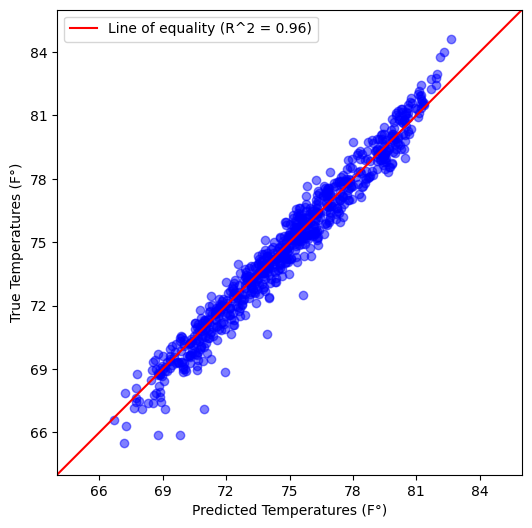

In [77]:
from matplotlib.ticker import MaxNLocator

plt.style.use('default')

plt.figure(figsize=(6, 12))

# Scatter plot
plt.scatter(preds_fahrenheit.numpy(), y_plot_fahrenheit.numpy(), alpha=0.5, color='blue')

# Line of equality
plt.plot(x_plot_f, y_plot_f, label=f'Line of equality (R^2 = {r2:.2f})', color='red')

# Set limits for both axes
plt.xlim(64, 86)
plt.ylim(64, 86)

# Make sure the aspect ratio is equal to ensure equal scaling
plt.gca().set_aspect('equal', adjustable='box')

# Set x and y ticks to be whole numbers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Labels and legend
plt.xlabel("Predicted Temperatures (F°)")
plt.ylabel("True Temperatures (F°)")
plt.legend()

# Show plot
plt.show()

## Attempt 2

In [ ]:
device = DEVICE

In [ ]:
N_BACKGROUND = 100
N_SAMPLES = 200

TOTAL = N_BACKGROUND + N_SAMPLES

x_cube_all, x_emb_all = collect_samples(train_loader, TOTAL)

background_cube = x_cube_all[:N_BACKGROUND].to(device)
background_emb = x_emb_all[:N_BACKGROUND].to(device)

test_cube = x_cube_all[N_BACKGROUND:TOTAL].to(device)
test_emb = x_emb_all[N_BACKGROUND:TOTAL].to(device)

print("background_cube:", background_cube.shape)  # [50, 100, 4, 5, 5]
print("test_cube:", test_cube.shape)              # [100, 100, 4, 5, 5]

background_cube: torch.Size([100, 100, 4, 5, 5])
test_cube: torch.Size([200, 100, 4, 5, 5])


In [ ]:
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x_cube, x_emb):
        out = self.model(x_cube, x_emb)   # [B]
        return out.unsqueeze(-1)          # ✅ [B, 1]

In [ ]:
wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

ModelWrapper(
  (model): TimeSeriesViTRegressor(
    (spatial_encoder): SpatialCubeEncoder(
      (token_proj): Linear(in_features=4, out_features=128, bias=True)
      (conv): Sequential(
        (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(32, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (encoder): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=512, bias=True)
            (dropout): Dropout(p=0, inplace=False)
            (linear2): Linear(in_features=512, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, eleme

In [ ]:
explainer = shap.GradientExplainer(
    wrapped_model,
    [background_cube, background_emb]
)

In [ ]:
shap_values = explainer.shap_values([test_cube, test_emb])

In [ ]:
shap_cube = shap_values[0]  # [N, T, C, H, W]

# Mean absolute contribution across time + space
shap_band = np.mean(np.abs(shap_cube), axis=(1, 3, 4))
# shape → [N, C=4]

In [ ]:
shap_band = np.array(shap_band)
shap_band = shap_band.reshape(shap_band.shape[0], -1)  # (N, 4)

features = shap_band.copy()

In [ ]:
feature_names = ['Blue', 'Green', 'Red', 'NIR']

/tmp/ipykernel_9484/247981082.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


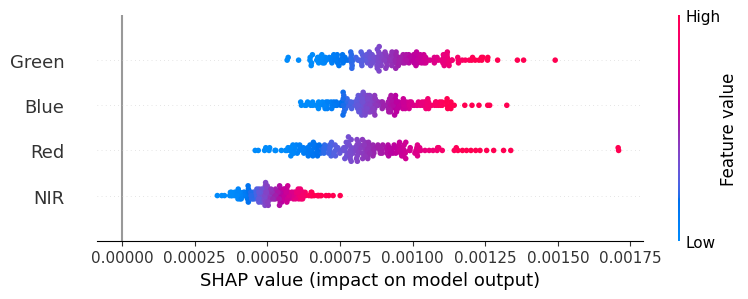

In [ ]:
shap.summary_plot(
    shap_values=shap_band,
    features=features,
    feature_names=['Blue', 'Green', 'Red', 'NIR'],
    plot_type="dot"
)

# Export Green Loop predictions

In [ ]:
5

5